In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [3]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [ ]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025


In [5]:
df_pf_2025.groupby('eleg_group').size() 

eleg_group
catchup_2024                      92386
catchup_2025                      52026
seasonal_2024                     86002
seasonal_2025                     90220
seasonal_2025_and_catchup_2024    13391
dtype: int64

In [6]:
df_pf_2025.groupby('eleg_group').agg({'fechaInm':'min','RUN':'nunique'})

,fechaInm,RUN
eleg_group,,
catchup_2024,2024-03-26,81874
catchup_2025,2024-11-01,48500
seasonal_2024,2024-04-01,77270
seasonal_2025,2025-03-01,86180
seasonal_2025_and_catchup_2024,2024-10-01,12337


In [108]:
df_pf_2025.assign(mes_nac = lambda x: x.fecha_nac.dt.month).groupby(['mes_nac','eleg_group']).RUN.nunique().unstack().fillna(0)

eleg_group,catchup_2024,catchup_2025,exceso_seasonal_2024_and_catchup_2025,seasonal_2024,seasonal_2025
mes_nac,,,,,
1,14330.0,12950.0,0.0,0.0,0.0
2,13050.0,11613.0,0.0,0.0,0.0
3,13932.0,0.0,0.0,0.0,12747.0
4,0.0,0.0,0.0,13625.0,12681.0
5,0.0,0.0,0.0,13314.0,12616.0
6,0.0,0.0,0.0,12486.0,11907.0
7,0.0,0.0,0.0,12763.0,12102.0
8,0.0,0.0,0.0,12710.0,11818.0
9,0.0,0.0,0.0,12372.0,12309.0


In [104]:
df_pf_2025.groupby('eleg_2024').RUN.size()

eleg_2024
CATCH_UP             92386
SEASONAL             86002
no_elegible_2024    155637
Name: RUN, dtype: int64

In [103]:
df_pf_2025.groupby('eleg_2025').RUN.size()

eleg_2025
CATCH_UP             65417
SEASONAL             90220
no_elegible_2025    178388
Name: RUN, dtype: int64

In [7]:
with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)
    
(df_pf_2025
 .query('(eleg_group=="catchup_2024") & (fechaInm.dt.year == 2025)')
 .assign(cardio = lambda x: x.RUN.isin(lista_ruts_cardio).astype(int),
        hard_preterm = lambda x: ((x.SEMANAS < 32) | (x.PESO < 1500)).astype(int),
        high_risk = lambda x: np.where((x.hard_preterm == 1) | (x.cardio == 1),1,0)
        )
 [['RUN','SEMANAS','PESO','fecha_nac','fechaInm','cardio','hard_preterm','high_risk']]
 )

,RUN,SEMANAS,PESO,fecha_nac,fechaInm,cardio,hard_preterm,high_risk
605,1f7b23e8cb5ec9d557c6ff0f76ea9578c7cbc6a121cffe51b7d35c6c16f56755,40.0,3452.0,2023-10-01,2025-08-13,0,0,0
3214,ffa592eb236438a0eb90b37253a08937fc02aab50664b1c31f74882ca88c694c,39.0,3085.0,2023-10-05,2025-04-17,0,0,0
7478,6407f972c0dadb27d94ed3e81df50ad66eaaa832dd2f5167e1e6ee803a61ca42,38.0,3530.0,2023-10-11,2025-09-29,0,0,0
10000,e5841e9cdbdf13e6442e2bb69fa8cd403aad1dc41dce3023b923bc536fcfbb99,37.0,3380.0,2023-10-20,2025-09-10,0,0,0
10001,e5841e9cdbdf13e6442e2bb69fa8cd403aad1dc41dce3023b923bc536fcfbb99,37.0,3380.0,2023-10-20,2025-09-10,0,0,0
...,...,...,...,...,...,...,...,...
241052,d3a3515f9e41100510bdea3790a0c4667a42c037d29940580a13c81acc2afb3a,33.0,1855.0,2024-02-23,2025-03-17,0,0,0
243471,96608697e41dc5408dc8fe4b34a0051322439b9646b789359fed4de50b9a9519,38.0,3205.0,2024-02-27,2025-03-17,0,0,0
244729,5b4464153119b441bb017c825bce7eae25e9e0021312f6ce4d0b42fb8a9dea7d,39.0,3460.0,2024-03-02,2025-03-03,0,0,0
249684,c620a1e8da3069e5a283cc3bfb5a654724162b483659150ca90428cd1fd21783,40.0,3300.0,2024-03-16,2025-03-21,0,0,0


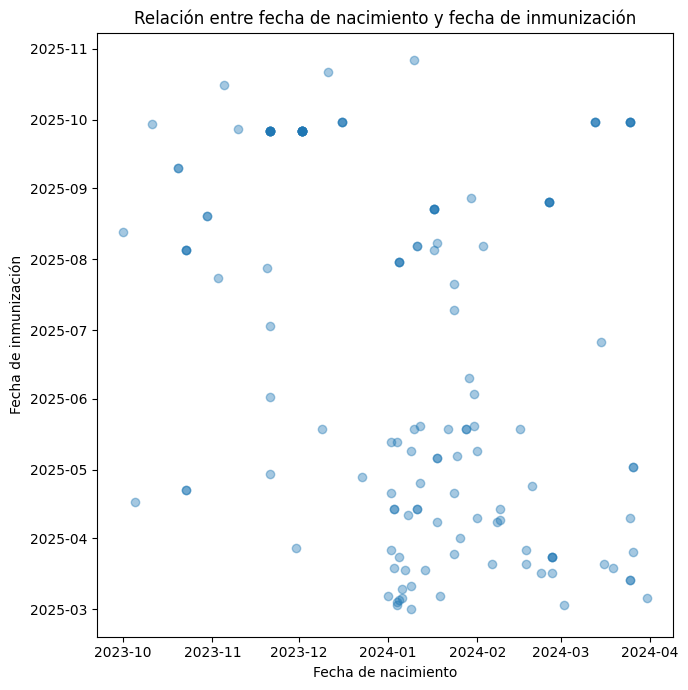

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

df_ploted = df_pf_2025.query('(eleg_group=="catchup_2024") & (fechaInm.dt.year == 2025)') #& (fechaInm.dt.year == 2025)

ax.scatter(
    df_ploted['fecha_nac'],
    df_ploted['fechaInm'],
    alpha=0.4
)

ax.set_xlabel("Fecha de nacimiento")
ax.set_ylabel("Fecha de inmunización")
ax.set_title("Relación entre fecha de nacimiento y fecha de inmunización")

plt.tight_layout()
plt.show()


In [9]:
df_pf_2025.query('(eleg_group=="seasonal_2025_and_catchup_2024")')[['RUN','SEMANAS','PESO','fecha_nac','fechaInm']]

,RUN,SEMANAS,PESO,fecha_nac,fechaInm
135841,3c31cd20e67983bbcbcb61c7592af2e821096926c69252ab168bf54bce450a90,39.0,3725.0,2024-10-04,2024-10-07
135883,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,40.0,3440.0,2024-10-01,2024-10-01
135884,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,40.0,3440.0,2024-10-01,2024-10-01
135885,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,40.0,3440.0,2024-10-01,2024-10-01
135888,b885ca16ebdb99ebb3e68e45d41fc480923d3dd11e375810bcf76d036c34579b,38.0,2235.0,2024-10-02,2024-10-02
...,...,...,...,...,...
225105,c1db9108ee67257b7afd952801e4bbea951fe09546c416dcf48049237b203e3e,40.0,3920.0,2024-10-26,2024-10-27
225106,c1db9108ee67257b7afd952801e4bbea951fe09546c416dcf48049237b203e3e,40.0,3920.0,2024-10-26,2024-10-27
225728,1f0db7ba225be39fdb504b7825977bee899bd6cd99095d715211a7cb6a68c9e1,38.0,3585.0,2024-10-28,2025-03-24
235747,fd45c1d28cef475e58415131eccaac69cf243a474add50d193492297f0f14641,39.0,3970.0,2024-10-03,2024-10-03


In [10]:
df_f_any, df_f_LRTI, df_f_vrs_25, df_f_upc_25 = filtros_IH_new(df_pf_2025,cohort='2025')
df_f_any, df_f_LRTI, df_f_vrs_24, df_f_upc_24 = filtros_IH_new(df_pf_2025,cohort='2024')
df_f_any, df_f_LRTI, df_f_vrs_both, df_f_upc_both = filtros_IH_new(df_pf_2025,cohort='both')

Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de nacer: 1
Ruts eliminados: 4399
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  9
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  2
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  14
fechaIng_any Reemplazos n/a net 7 days inmunizado:  439
Datos perdidos por muertes:  1521
ruts perdidos por filtro semanas y peso:  535
Droped intersex: 22
Datos perdidos por edad madre atípica: 213
Datos perdidos por fecha ingreso menor a fecha nacimiento: 19
vrs en los primeros 7 dias de nacer: 3
Ruts eliminados: 2837
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  25
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  6
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  33
fechaIng_any Reemplazos n/a net 7 days inmunizado:  497
Datos perdidos por muertes

In [60]:
df_pf_2025.assign(ano_inm = lambda x: x.fechaInm.dt.year).groupby('ano_inm').fechaInm.max()

ano_inm
2024.0   2024-12-17
2025.0   2025-11-27
Name: fechaInm, dtype: datetime64[ns]

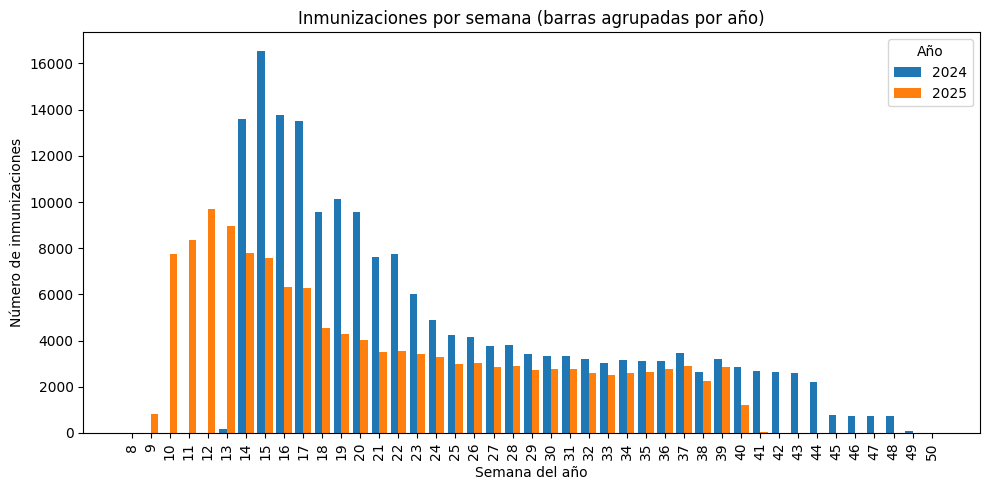

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_plot = (
    df_pf_2025
    .dropna(subset=['fechaInm'])
    .assign(
        ano_inm=lambda d: d.fechaInm.dt.year,
        semana=lambda d: d.fechaInm.dt.isocalendar().week.astype(int)
    )
)

# Conteos por semana y año
weekly_counts = (
    df_plot
    .groupby(['ano_inm', 'semana'])
    .size()
    .reset_index(name='n')
)
years = sorted(weekly_counts['ano_inm'].unique())
weeks = np.arange(8, 51)

bar_width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))

for i, year in enumerate(years):
    y = (
        weekly_counts
        .loc[weekly_counts['ano_inm'] == year]
        .set_index('semana')
        .reindex(weeks, fill_value=0)['n']
    )

    ax.bar(
        weeks + (i - 0.5) * bar_width,
        y,
        width=bar_width,
        label=str(year)
    )

ax.set_xlabel("Semana del año")
ax.set_ylabel("Número de inmunizaciones")
ax.set_title("Inmunizaciones por semana (barras agrupadas por año)")

ax.set_xticks(weeks)
ax.set_xticklabels(weeks, rotation=90)

ax.legend(title="Año")

plt.tight_layout()
plt.show()


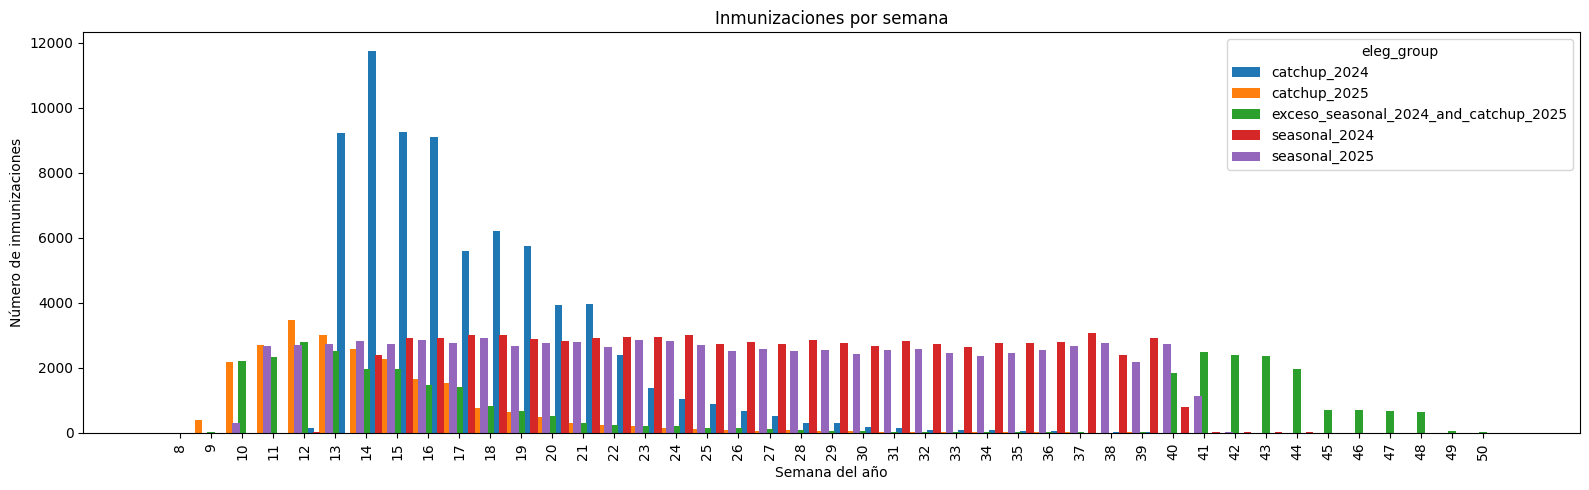

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_plot = (
    df_pf_2025
    .dropna(subset=['fechaInm'])
    .assign(
        ano_inm=lambda d: d.fechaInm.dt.year,
        semana=lambda d: d.fechaInm.dt.isocalendar().week.astype(int)
    )
)

# Conteos por semana y año
weekly_counts = (
    df_plot
    .groupby(['eleg_group', 'semana'])
    .RUN.nunique()
    .reset_index(name='n')
)
years = sorted(weekly_counts['eleg_group'].unique())
weeks = np.arange(8, 51)

bar_width = 0.25
gap = 0.4
fig, ax = plt.subplots(figsize=(16, 5))

for i, year in enumerate(years):
    y = (
        weekly_counts
        .loc[weekly_counts['eleg_group'] == year]
        .set_index('semana')
        .reindex(weeks, fill_value=0)['n']
    )

    ax.bar(
        weeks + (i - (len(years)-1)/2) * gap,
        y,
        width=bar_width,
        label=str(year)
    )

ax.set_xlabel("Semana del año")
ax.set_ylabel("Número de inmunizaciones")
ax.set_title("Inmunizaciones por semana")

ax.set_xticks(weeks)
ax.set_xticklabels(weeks, rotation=90)

ax.legend(title="eleg_group")

plt.tight_layout()
plt.show()


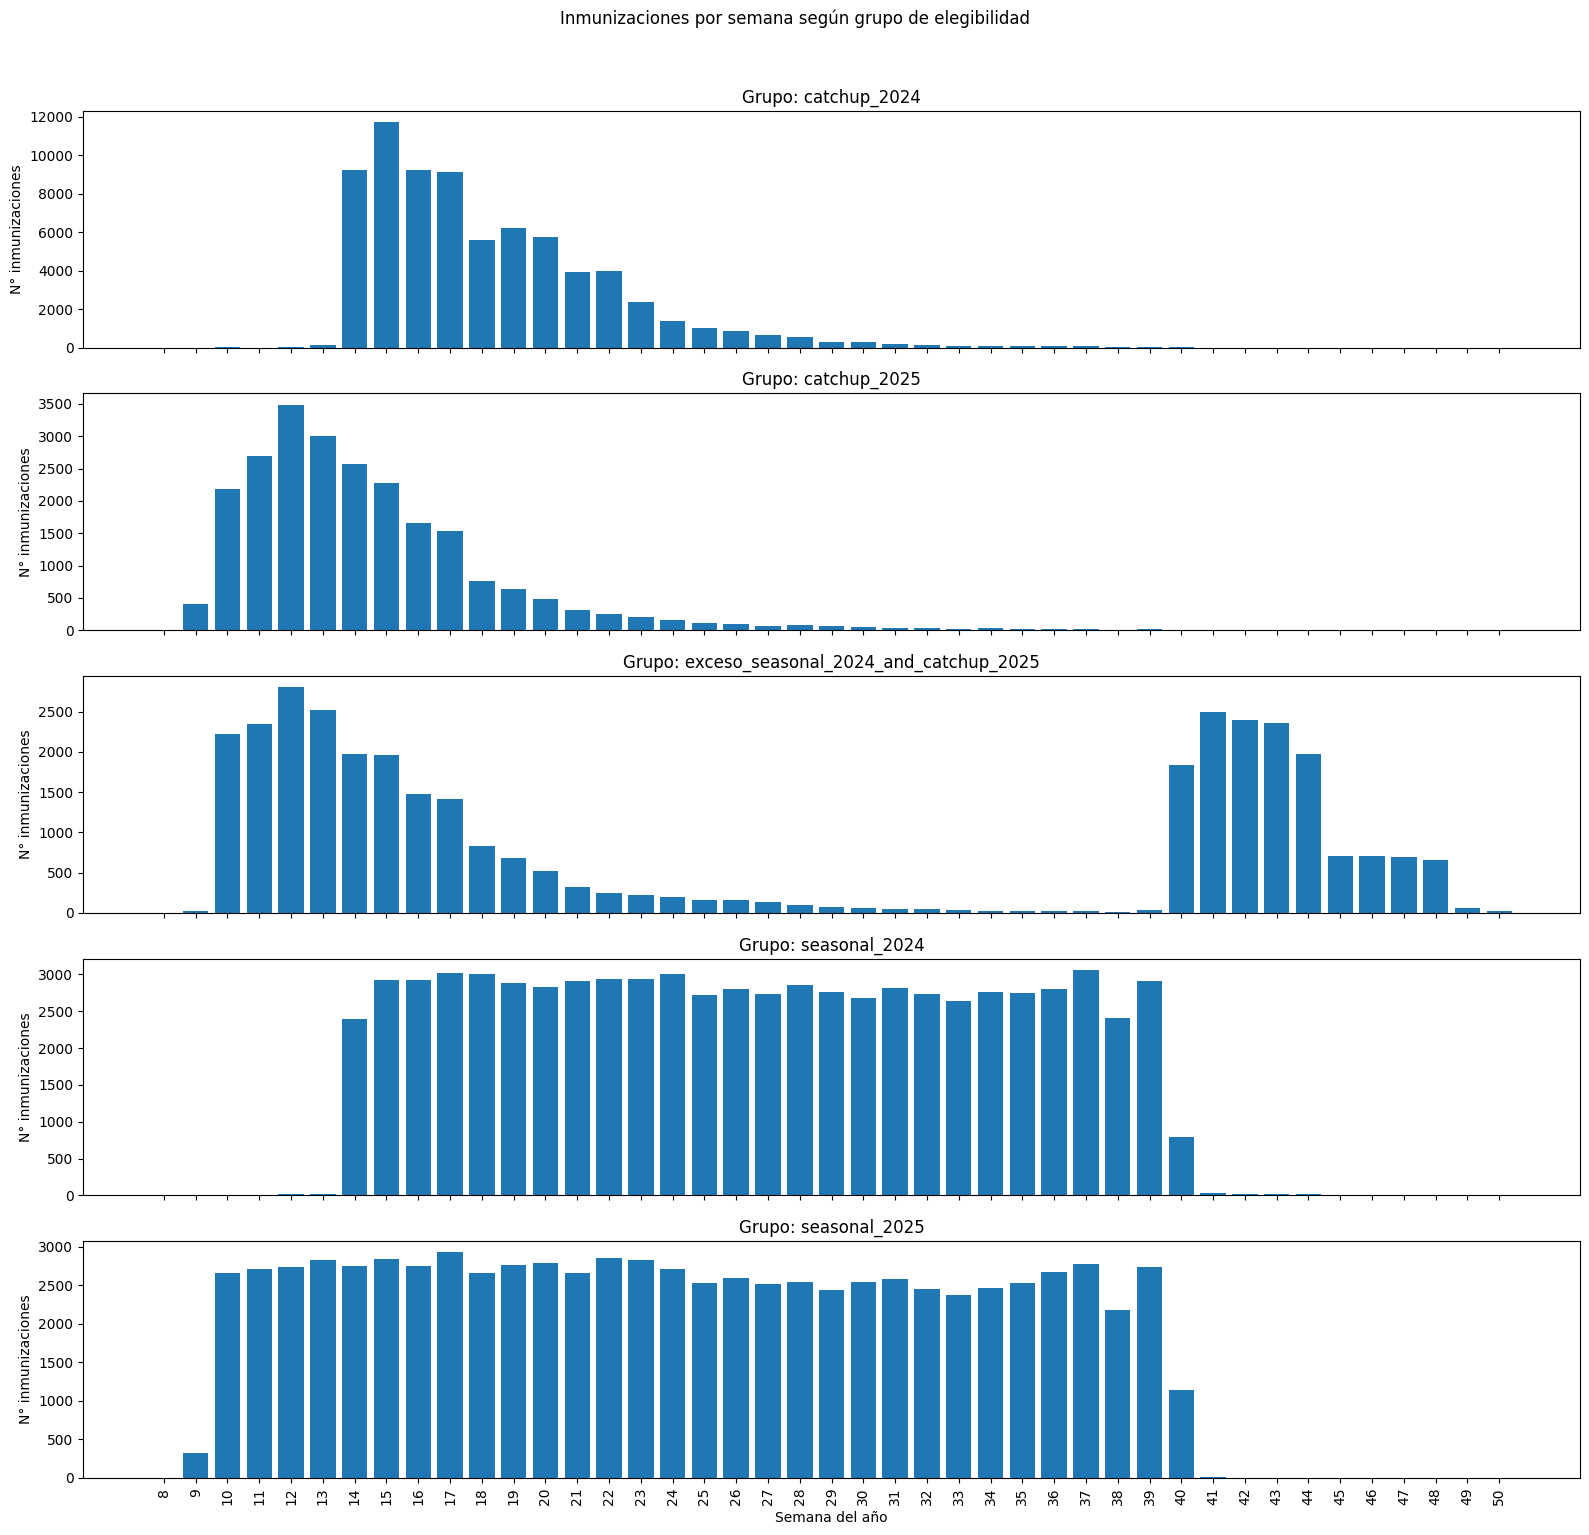

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Preparación de datos
# -----------------------------
df_plot = (
    df_pf_2025
    .dropna(subset=['fechaInm'])
    .assign(
        ano_inm=lambda d: d.fechaInm.dt.year,
        semana=lambda d: d.fechaInm.dt.isocalendar().week.astype(int)
    )
)

weekly_counts = (
    df_plot
    .groupby(['eleg_group', 'semana'])
    .RUN.nunique()
    .reset_index(name='n')
)

groups = sorted(weekly_counts['eleg_group'].unique())
weeks = np.arange(8, 51)

# -----------------------------
# Subplots: uno por eleg_group
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(groups),
    ncols=1,
    figsize=(16, 3 * len(groups)),
    sharex=True
)

# Si hay solo un grupo, axes no es iterable
if len(groups) == 1:
    axes = [axes]

for ax, group in zip(axes, groups):
    y = (
        weekly_counts
        .loc[weekly_counts['eleg_group'] == group]
        .set_index('semana')
        .reindex(weeks, fill_value=0)['n']
    )

    ax.bar(
        weeks,
        y,
        width=0.8
    )

    ax.set_title(f"Grupo: {group}")
    ax.set_ylabel("N° inmunizaciones")

# -----------------------------
# Ejes comunes y formato
# -----------------------------
axes[-1].set_xlabel("Semana del año")
axes[-1].set_xticks(weeks)
axes[-1].set_xticklabels(weeks, rotation=90)

fig.suptitle("Inmunizaciones por semana según grupo de elegibilidad", y=1.02)

plt.tight_layout()
plt.show()


In [11]:
df_f_vrs_24.RUN.nunique(),df_f_vrs_25.RUN.nunique(), df_f_vrs_both.RUN.nunique()

(154490, 141081, 295528)

In [12]:
df_f_vrs_24.eleg_group.value_counts()

eleg_group
catchup_2024     79340
seasonal_2024    75150
Name: count, dtype: int64

In [13]:
df_f_vrs_25.eleg_group.value_counts()

eleg_group
seasonal_2025                     81787
catchup_2025                      47225
seasonal_2025_and_catchup_2024    12069
Name: count, dtype: int64

In [14]:
df_f_vrs_both.eleg_group.value_counts()

eleg_group
seasonal_2025                     81784
catchup_2024                      79340
seasonal_2024                     75150
catchup_2025                      47185
seasonal_2025_and_catchup_2024    12069
Name: count, dtype: int64

In [15]:
df_f_vrs_both_c25 = df_f_vrs_both.query('eleg_group=="catchup_2025"')
df_f_vrs_25_c25 = df_f_vrs_25.query('eleg_group=="catchup_2025"')

In [16]:
df_f_vrs_25_c25.RUN.nunique(),df_f_vrs_both_c25.RUN.nunique()

(47225, 47185)

In [ ]:
lista_ruts_search = df_f_vrs_25_c25.query('~(RUN.isin(@df_f_vrs_both_c25.RUN.unique()))').RUN.unique()

In [41]:
df_pf_2025[['RUN','fecha_nac']].duplicated(keep=False)

0         False
1         False
2          True
3          True
4          True
          ...  
334020    False
334021    False
334022    False
334023    False
334024    False
Length: 334025, dtype: bool

In [37]:
df_pf_2025[df_pf_2025['RUN'].duplicated(keep=False)] #[['RUN','fecha_nac','fechaInm','event_vrs','fechaIng_vrs']]

,RUN,RUN_RNI,RUN_M,VACUNADO,MARCA,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,FECHA_DEFUNCION,CAUSA_DEFUNCION,VIVO,FALLECIDO_PREVIO,ESTAB,ServicioSalud,Seremi,P_ORIGEN,PREVI,FECHA_INGRESO,FECHA_EGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,AREAF_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,NOMBRE_REGION,Porcentaje Urbano,porcent_rural,percent_poor_multidim,percent_poor,p_00001_lognormal,p_99999_lognormal,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,fecha_nac,fechaIng_any,fechaEgr,fechaInm,VRS_D1,VRS_D1y3,VRS_Dall,diag_irag,diag_ira_alta,LRTI_Flag,LRTI_all_j,LRTI_Flag_Dall,fechaIng_vrs,fechaIng_LRTI,fechaIng_vrs_Dall,fechaIng_LRTI_Dall,eleg_group,eleg_2025,eleg_2024,group,sexo,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,atypic_mom_age,region,Macrozona2,cama,fecha_upc,fecha_upc_vrs,fecha_upc_vrs_Dall,days_upc,dias_en_ing,days_estad_vrs,days_estad_vrs_Dall,is_rural,categori_macro,categori_regions,exp_rural,is_poor,vrs_pre_campaña_2024,lrti_pre_campaña_2024,any_pre_campaña_2024,upc_pre_campaña_2024,vrs_pre_campaña_2025,lrti_pre_campaña_2025,any_pre_campaña_2025,upc_pre_campaña_2025,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,days_upc_vrs,days_upc_vrs_Dall,event_upc,event_upc_Dall,event_vrs,event_vrs_Dall,event_LRTI,event_any,take_nirse
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,1,dd8de0efd088596dff438fb015413bd2545cce2da1640946d687c9aac8b84cd2,SI,0,01OCT2023,10,2023,2,34.0,1815.0,42.0,16,3,2,13127,13127,13.0,0,C,2024-05-28,NaN,NaN,SI,VIVO,109100.0,9.0,NaN,152.0,1.0,01OCT2023,08NOV2023,1,311.0,8.0,10.0,2023.0,1,324.0,6.0,11.0,2023.0,0,152.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,38.0,1.0,P009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Región Metropolitana de Santiago,1.000000,0.000000,0.211601,5.139076,1377.890820,3803.094627,2023-10-08,2023-11-06,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2023-10-01,2023-10-01,2023-11-08,2024-05-28,0,0,0,False,False,False,False,False,NaT,NaT,NaT,NaT,catchup_2024,no_elegible_2025,CATCH_UP,CATCH_UP,0,0,0,1,1,1,METROPOLITANA,Centro,UPC,2023-10-01,NaT,NaT,36,7,0.0,0.0,0,1,12,1.000000,1,0,0,1,0,0,0,0,0,29,2,0,0,0,0,0,0,0,0,0,False,False,False,False,False,True,True
3,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,1,dd8de0efd088596dff438fb015413bd2545cce2da1640946d687c9aac8b84cd2,SI,0,01OCT2023,10,2023,2,34.0,1815.0,42.0,16,3,2,13127,13127,13.0,0,C,2024-05-28,NaN,NaN,SI,VIVO,109101.0,9.0,NaN,152.0,1.0,26AUG2025,27AUG2025,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,1.0,1.0,J209,NaN,J960,J981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Región Metropolitana de Santiago,1.000000,0.000000,0.211601,5.139076,1377.890820,3803.094627,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2023-10-01,2025-08-26,2025-08-27,2024-05-28,0,0,0,True,False,True,True,True,NaT,2025-08-26,NaT,2025-08-26,catchup_2024,no_elegible_2025,CATCH_UP,CATCH_UP,0,0,0,1,1,1,METROPOLITANA,Centro,,NaT,NaT,NaT,0,0,0.0,0.0,0,1,12,1.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True,True,True
4,28b7db82

In [51]:
df_pf_2025.query('RUN.isin(@pairs_diff.RUN.unique())').FECHA_INMUNIZACION.describe()

count                               86
mean     2025-04-18 02:13:57.209302272
min                2025-03-01 00:00:00
25%                2025-03-17 00:00:00
50%                2025-04-01 00:00:00
75%                2025-05-12 00:00:00
max                2025-08-28 00:00:00
Name: FECHA_INMUNIZACION, dtype: object

RUN duplicados con fecha_nac distinta (entre 1ª y 2ª aparición): 44


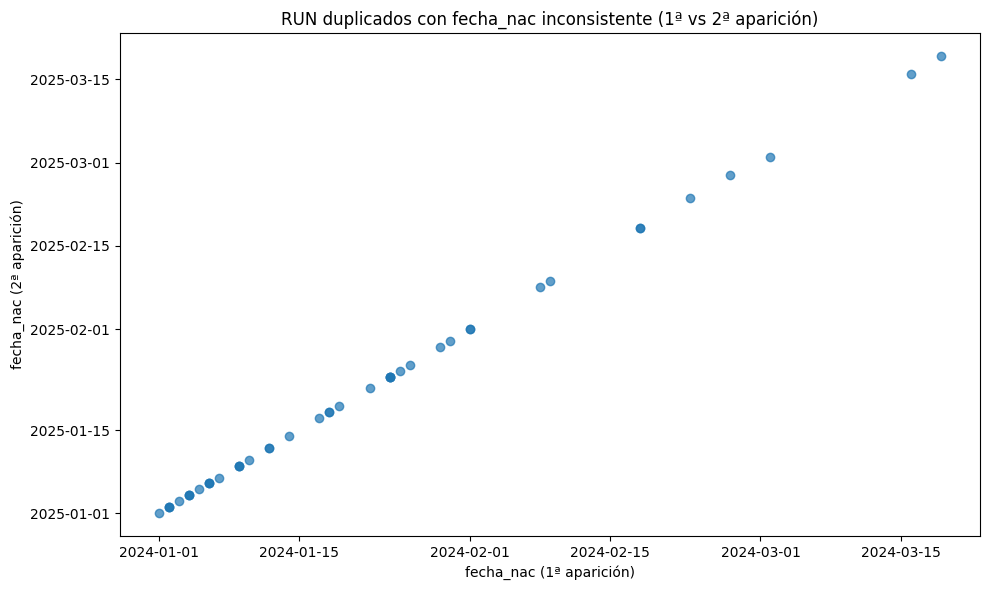

RUN duplicados totales: 17341
RUN duplicados con fecha_nac distinta: 44
Porcentaje inconsistente: 0.25%


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Quedarse con RUN duplicados (todas sus apariciones) y la columna relevante
df_dups = df_pf_2025.loc[
    df_pf_2025['RUN'].duplicated(keep=False),
    ['RUN', 'fecha_nac']
].copy()

# 2) Definir "1ª" y "2ª aparición" (aquí uso el orden original del DataFrame)
#    Si prefieres otro criterio (p.ej., fechaIng_vrs), cámbialo en sort_values.
df_dups = df_dups.sort_values(['fecha_nac'])  # estable si el índice ya refleja el orden de aparición

# 3) Construir pares (primera y segunda fila por RUN)
pairs = (
    df_dups
    .groupby('RUN')['fecha_nac']
    .agg(
        fecha_nac_1=lambda x: x.iloc[0],
        fecha_nac_2=lambda x: x.iloc[1]
    )
    .reset_index()
)

# 4) Filtrar SOLO los RUN donde difieren
pairs_diff = pairs.loc[pairs['fecha_nac_1'] != pairs['fecha_nac_2']].copy()

# (Opcional) ver cuántos son
print("RUN duplicados con fecha_nac distinta (entre 1ª y 2ª aparición):", len(pairs_diff))

# 5) Scatter plot X vs Y
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    pairs_diff['fecha_nac_1'],
    pairs_diff['fecha_nac_2'],
    alpha=0.7
)

# Diagonal y = x para referencia
# if not pairs_diff.empty:
#     min_date = min(pairs_diff['fecha_nac_1'].min(), pairs_diff['fecha_nac_2'].min())
#     max_date = max(pairs_diff['fecha_nac_1'].max(), pairs_diff['fecha_nac_2'].max())
#     ax.plot([min_date, max_date], [min_date, max_date], linestyle='--')

ax.set_xlabel("fecha_nac (1ª aparición)")
ax.set_ylabel("fecha_nac (2ª aparición)")
ax.set_title("RUN duplicados con fecha_nac inconsistente (1ª vs 2ª aparición)")

plt.tight_layout()
plt.show()

n_bad = len(pairs_diff)
n_dups = len(pairs)

print(f"RUN duplicados totales: {n_dups}")
print(f"RUN duplicados con fecha_nac distinta: {n_bad}")
print(f"Porcentaje inconsistente: {100 * n_bad / n_dups:.2f}%")



Ya, claramente hay 44 ruts que deben tener error de tipeo en data, dado que tienen la misma fecha de nac, excpeto en año y el resto igual. Se queda el registro que sea consistente con fecha inmunización. El resto de duplicados son debido a múltiples egresos.

EMPIEZO A REPLICAR COSAS DE PAPER PASADO...

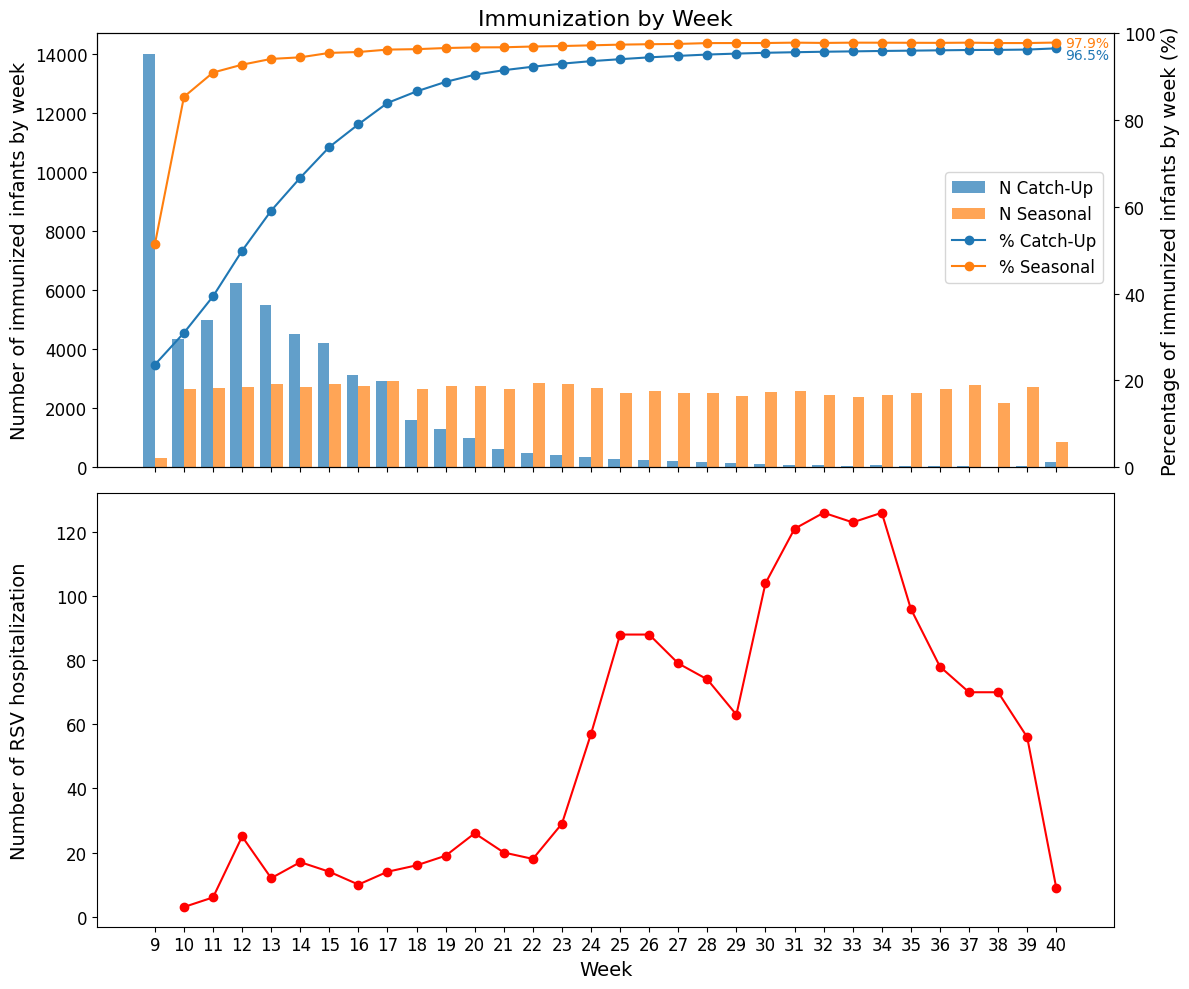

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales del primer gráfico
df_vrs_tilweek_edit = df_f_vrs_25.copy()

nacimientos_normal = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .unstack(0)
    .fillna(0)
    .query("week >= 8")
)

nacimientos_cumsum = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .reset_index(name='count')
    .pivot(index='week', columns='eleg_2025', values='count')
    .fillna(0)
    .cumsum()
    .query("week >= 8")
)

# Incorporamos valores acumulados en nacimientos_normal
nacimientos_normal['CATCH_UP'] = nacimientos_cumsum['CATCH_UP']
nacimientos_normal['SEASONAL'] = nacimientos_cumsum['SEASONAL']

grafico_campaign = (
    df_vrs_tilweek_edit
    .query('fechaInm.notna()')
    # .assign(week = lambda x: np.where(x.fechaInm.dt.isocalendar().week==13,
    #                                   x.fechaInm.dt.isocalendar().week+1,
    #                                   x.fechaInm.dt.isocalendar().week))
    .assign(week = lambda x: x.fechaInm.dt.isocalendar().week)
    .groupby(['eleg_2025','week'])
    .size()
    .unstack(0)
    .fillna(0)
    .merge(nacimientos_normal, how='left', on=['week'])
    .rename(columns={
        'CATCH_UP_x': 'Catch_Campaña',
        'SEASONAL_x': 'Seasonal_Campaña',
        'CATCH_UP_y': 'Catch_Nacimientos',
        'SEASONAL_y': 'Seasonal_Nacimientos'
    })
    # Porcentajes acumulados
    .assign(Porcentaje_inmune_catchup = lambda x: 100 * x['Catch_Campaña'].cumsum() / x['Catch_Nacimientos'],
            Porcentaje_inmune_seasonal = lambda x: 100 * x['Seasonal_Campaña'].cumsum() / x['Seasonal_Nacimientos'])
    .reset_index()
)

df = grafico_campaign


# Datos para el segundo gráfico (RSV)
vrs_normal = (
    df_vrs_tilweek_edit
    .query('fechaIng_vrs.notna()')
    .assign(
        week=lambda x: x.fechaIng_vrs.dt.isocalendar().week
    )
    .groupby(['week'], as_index=False)
    .size()
    .rename(columns={'size':'casos_vrs'})
    .fillna(0)
)

# Suavizamos un poco la serie de casos VRS usando un rolling mean
# (ajusta la ventana como desees)
vrs_normal['casos_vrs_suav'] = vrs_normal['casos_vrs'].rolling(window=1, center=True).mean()
# Llenamos valores NaN al inicio y fin (por la ventana de rolling) para no tener "huecos"
vrs_normal['casos_vrs_suav'] = vrs_normal['casos_vrs_suav'].fillna(method='bfill').fillna(method='ffill')


# Creamos la figura con dos subplots, compartiendo el eje X
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#### GRÁFICO SUPERIOR (inmunización) ####
catch_color = '#1f77b4'    # Azul (Catch)
seasonal_color = '#ff7f0e' # Naranja (Seasonal)

bar1 = ax_top.bar(df['week'] - 0.2, df['Catch_Campaña'], width=0.4, label='N Catch-Up', color=catch_color, alpha=0.7)
bar2 = ax_top.bar(df['week'] + 0.2, df['Seasonal_Campaña'], width=0.4, label='N Seasonal', color=seasonal_color, alpha=0.7)

ax_top.set_ylabel('Number of immunized infants by week', color='black', fontsize=14)
ax_top.tick_params(axis='x', labelsize=12)
ax_top.tick_params(axis='y', labelsize=12)
ax_top.set_xticks(df['week'])

ax_top2 = ax_top.twinx()
line1, = ax_top2.plot(df['week'], df['Porcentaje_inmune_catchup'], marker='o', color=catch_color, label='% Catch-Up')
line2, = ax_top2.plot(df['week'], df['Porcentaje_inmune_seasonal'], marker='o', color=seasonal_color, label='% Seasonal')
ax_top2.set_ylabel('Percentage of immunized infants by week (%)', color='black', fontsize=14)
ax_top2.tick_params(axis='y', labelsize=12)
ax_top2.set_ylim(0, 100)

# Texto final en las curvas
last_week = df['week'].iloc[-1]
final_catchup = df['Porcentaje_inmune_catchup'].iloc[-1]
final_seasonal = df['Porcentaje_inmune_seasonal'].iloc[-1]

ax_top2.text(last_week + 0.3, final_catchup, f'{final_catchup:.1f}%', color=catch_color, va='top', fontsize=10)
ax_top2.text(last_week + 0.3, final_seasonal, f'{final_seasonal:.1f}%', color=seasonal_color, va='center', fontsize=10)

lines = [bar1, bar2, line1, line2]
labels = ['N Catch-Up', 'N Seasonal', '% Catch-Up', '% Seasonal']
fig.legend(lines, labels, loc='upper right', ncol=1, bbox_to_anchor=(0.93, 0.83), fontsize=12)

ax_top.set_title('Immunization by Week', fontsize=16)


#### GRÁFICO INFERIOR (RSV) ####
# Graficamos la línea suavizada de casos de VRS
ax_bottom.plot(vrs_normal['week'], vrs_normal['casos_vrs_suav'], marker='o', color='red', label='RSV Hospitalization')
ax_bottom.set_ylabel('Number of RSV hospitalization', fontsize=14)
ax_bottom.tick_params(axis='y', labelsize=12)
ax_bottom.tick_params(axis='x', labelsize=12)
ax_bottom.set_xlabel('Week', fontsize=14)

# Ajustamos el layout
plt.tight_layout()
# plt.savefig(path_data/'immunization_and_circulation_by_week.png', dpi=400)
# plt.savefig(path_data/'immunization_and_circulation_by_week.eps', format='eps')
fig.align_ylabels([ax_top, ax_bottom])
plt.show()

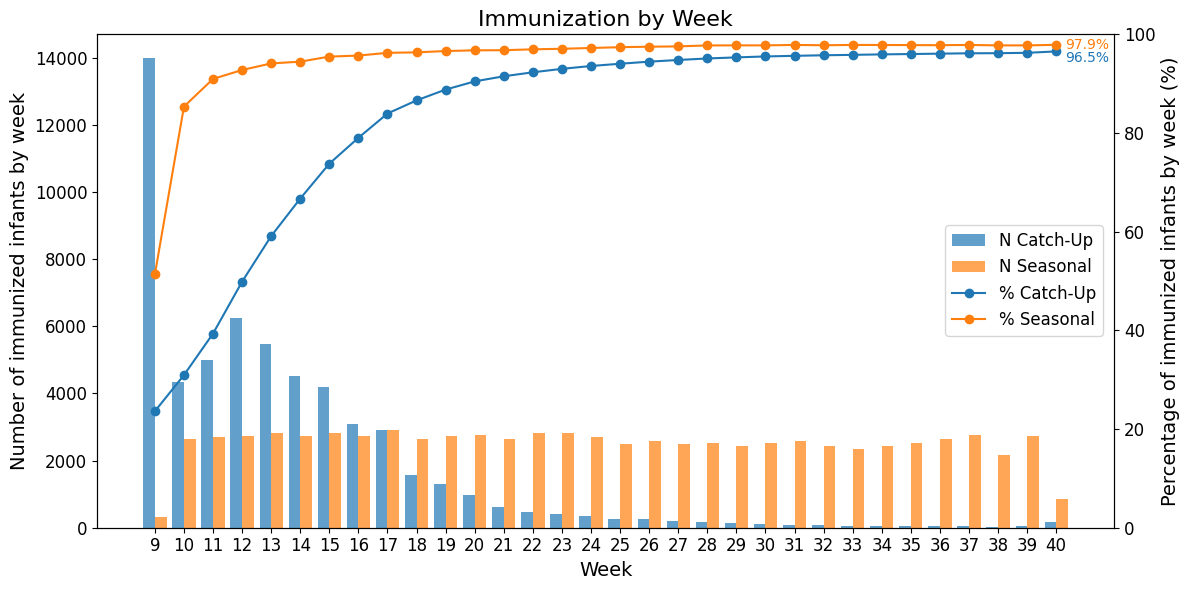

In [58]:
df_vrs_tilweek_edit = df_f_vrs #df_f_vrs_25

nacimientos_normal = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .unstack(0)
    .fillna(0)
    .query("week >= 5")
)

nacimientos_cumsum = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .reset_index(name='count')
    .pivot(index='week', columns='eleg_2025', values='count')
    .fillna(0)
    .cumsum()
    .query("week >= 5")
)

# Incorporar valores acumulados en nacimientos_normal
nacimientos_normal['CATCH_UP'] = nacimientos_cumsum['CATCH_UP']
nacimientos_normal['SEASONAL'] = nacimientos_cumsum['SEASONAL']

grafico_campaign = (
    df_vrs_tilweek_edit
    .query('fechaInm.notna()')
    # .assign(week = lambda x: np.where(x.fechaInm.dt.isocalendar().week==13,
    #                                   x.fechaInm.dt.isocalendar().week+1,
    #                                   x.fechaInm.dt.isocalendar().week))
    .assign(week = lambda x: x.fechaInm.dt.isocalendar().week)
    .groupby(['eleg_2025','week'])
    .size()
    .unstack(0)
    .fillna(0)
    .merge(nacimientos_normal,how='left',on=['week'])
    .rename(columns={
        'CATCH_UP_x': 'Catch_Campaña',
        'SEASONAL_x': 'Seasonal_Campaña',
        'CATCH_UP_y': 'Catch_Nacimientos',
        'SEASONAL_y': 'Seasonal_Nacimientos'
    })
    # Porcentajes acumulados
    .assign(Porcentaje_inmune_catchup = lambda x: 100 * x['Catch_Campaña'].cumsum() / x['Catch_Nacimientos'],
            Porcentaje_inmune_seasonal = lambda x: 100 * x['Seasonal_Campaña'].cumsum() / x['Seasonal_Nacimientos'])
    .reset_index()
)

df = grafico_campaign

fig, ax1 = plt.subplots(figsize=(12, 6))

catch_color = '#1f77b4'    # Azul (para Catch Campaña y % Catchup)
seasonal_color = '#ff7f0e' # Naranja (para Seasonal Campaña y % Seasonal)

bar1 = ax1.bar(df['week'] - 0.2, df['Catch_Campaña'], width=0.4, label='N Catch-Up', color=catch_color, alpha=0.7)
bar2 = ax1.bar(df['week'] + 0.2, df['Seasonal_Campaña'], width=0.4, label='N Seasonal', color=seasonal_color, alpha=0.7)
ax1.set_xlabel('Week', fontsize=14)
ax1.set_ylabel('Number of immunized infants by week', color='black', fontsize=14)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xticks(df['week'])

ax2 = ax1.twinx()
line1, = ax2.plot(df['week'], df['Porcentaje_inmune_catchup'], marker='o', color=catch_color, label='% Catch-Up')
line2, = ax2.plot(df['week'], df['Porcentaje_inmune_seasonal'], marker='o', color=seasonal_color, label='% Seasonal')
ax2.set_ylabel('Percentage of immunized infants by week (%)', color='black', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 100)

# Tomamos el último punto de cada curva para anotar el porcentaje final
last_week = df['week'].iloc[-1]

final_catchup = df['Porcentaje_inmune_catchup'].iloc[-1]
final_seasonal = df['Porcentaje_inmune_seasonal'].iloc[-1]

# Agregamos el texto al final de las curvas
ax2.text(last_week + 0.3, final_catchup, f'{final_catchup:.1f}%', color=catch_color, va='top', fontsize=10)
ax2.text(last_week + 0.3, final_seasonal, f'{final_seasonal:.1f}%', color=seasonal_color, va='center', fontsize=10)

lines = [bar1, bar2, line1, line2]
labels = ['N Catch-Up', 'N Seasonal', '% Catch-Up', '% Seasonal']
fig.legend(lines, labels, loc='upper right', ncol=1, bbox_to_anchor=(0.93, 0.63), fontsize=12)

plt.title('Immunization by Week', fontsize=16)
plt.tight_layout()
# plt.savefig(path_data/'immunization_by_week.png', dpi=400)
# plt.savefig(path_data/'immunization_by_week.eps', format='eps')
plt.show()

In [108]:
df_f = df_f_vrs_25

region_to_macrozone_isci = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona Centro",
    "O'HIGGINS": "Macrozona Centro",
    "MAULE": "Macrozona Sur",
    "NUBLE": "Macrozona Sur",
    "BIOBIO": "Macrozona Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

df_f["macrozona_isci"] = df_f["region"].map(region_to_macrozone_isci)

T_final_tabla = pd.to_datetime('2025-09-30')
df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = np.where(df_f.eleg_2025=='SEASONAL', (df_f['fechaInm'] - df_f['fecha_nac']).dt.days, (df_f['fechaInm'] - pd.to_datetime("2025-03-01")).dt.days)
df_f['age_at_cut_days'] = ((T_final_tabla - df_f['fecha_nac']).dt.days)
df_f['age_at_cut'] = df_f.age_at_cut_days / 30
df_f['ages_group'] = np.where(df_f['age_at_cut_days'] < 90, 1, np.where(df_f['age_at_cut_days'] <= 180, 2, 3))

total_overall = df_f.RUN.nunique()
total_non_recipients = df_f[df_f['inmunizado'] == 0].RUN.nunique()
total_recipients = df_f[df_f['inmunizado'] == 1].RUN.nunique()

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['sexo'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['sexo'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['sexo'].value_counts()

nationality_counts_overall = df_f['eleg_2025'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['eleg_2025'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['eleg_2025'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()
nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

# weight 
w_mean_sd_overall = (df_f['PESO'].mean(), df_f['PESO'].std())
w_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['PESO'].mean(), df_f[df_f['inmunizado'] == 0]['PESO'].std())
w_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['PESO'].mean(), df_f[df_f['inmunizado'] == 1]['PESO'].std())

w_median_overall = df_f['PESO'].median()
w_median_non_recipients = df_f[df_f['inmunizado'] == 0]['PESO'].median()
w_median_recipients = df_f[df_f['inmunizado'] == 1]['PESO'].median()

# preterm
df_f['preterm'] = np.where(df_f['SEMANAS']<37, 1, 0)
preterm_counts_overall = df_f['preterm'].value_counts()
preterm_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['preterm'].value_counts()
preterm_counts_recipients = df_f[df_f['inmunizado'] == 1]['preterm'].value_counts()

macrozone_all = df_f['macrozona_isci'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['macrozona_isci'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['macrozona_isci'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()

# Ahora calculamos mean y sd de time_to_imune por grupo (CATCH_UP y SEASONAL)
catchup_overall = df_f[df_f['eleg_2025'] == 'CATCH_UP']['time_to_imune']
seasonal_overall = df_f[df_f['eleg_2025'] == 'SEASONAL']['time_to_imune']

catchup_overall_mean_sd = (catchup_overall.median(), catchup_overall.quantile(0.75) - catchup_overall.quantile(0.25))
seasonal_overall_mean_sd = (seasonal_overall.median(), seasonal_overall.quantile(0.75) - seasonal_overall.quantile(0.25))

catchup_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['eleg_2025'] == 'CATCH_UP')]['time_to_imune']
catchup_non_rec_mean_sd = (catchup_non_recipients.median(), catchup_non_recipients.quantile(0.75) - catchup_non_recipients.quantile(0.25))

catchup_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['eleg_2025'] == 'CATCH_UP')]['time_to_imune']
catchup_rec_mean_sd = (catchup_recipients.median(), catchup_recipients.quantile(0.75) - catchup_recipients.quantile(0.25))

seasonal_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['eleg_2025'] == 'SEASONAL')]['time_to_imune']
seasonal_non_rec_mean_sd = (seasonal_non_recipients.median(), seasonal_non_recipients.quantile(0.75) - seasonal_non_recipients.quantile(0.25))

seasonal_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['eleg_2025'] == 'SEASONAL')]['time_to_imune']
seasonal_rec_mean_sd = (seasonal_recipients.median(), seasonal_recipients.quantile(0.75) - seasonal_recipients.quantile(0.25))

column_tuples = [
    ("Overall", f"(N={total_overall})"),
    ("Nirse recipients", f"(N={total_recipients})"),
    ("Nirse non recipients", f"(N={total_non_recipients})"),
    ("p-value", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Modificar la estructura de la tabla: en vez de Mean(SD) y Median en Time to immune,
# ahora tendremos "Catch-up" y "Seasonal".
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("","median (IQR)"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "Seasonal"),
    ("Time to immune (days)", ""), 
    (" ", "Catch-up"),    # Nueva fila en vez de Mean (SD)
    (" ", "Seasonal"),    # Nueva fila en vez de Median
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    #(" ", "Median"),
    ("Weight at birth (gr)", ""),
    ("  ", "Mean (SD)"),
    #("  ", "Median"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South"),
    ("", "Austral")
])

df_table = pd.DataFrame(index=row_index, columns=columns)

def val_pct(value, total):
    return f"{value} ({(value*100/total):.2f}%)"

# Edades
df_table.loc[("", "<3"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(1,0), total_overall)
df_table.loc[("", "<3"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(1,0), total_non_recipients)
df_table.loc[("", "<3"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(1,0), total_recipients)

df_table.loc[("", "3 to 6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(2,0), total_overall)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(2,0), total_non_recipients)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(2,0), total_recipients)

df_table.loc[("", ">6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(3,0), total_overall)
df_table.loc[("", ">6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(3,0), total_non_recipients)
df_table.loc[("", ">6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(3,0), total_recipients)

# df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f}) ({(df_f['age_at_cut'].quantile(0.75) - df_f['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f})"

df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75)):.2f})"

# Sexo
df_table.loc[("", "Female"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "Female"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "Female"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Male"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Male"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Male"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(1, 0), total_recipients)

# Season group
df_table.loc[("", "Catch-up"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('CATCH_UP', 0), total_overall)
df_table.loc[("", "Seasonal"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('SEASONAL', 0), total_overall)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('CATCH_UP', 0), total_non_recipients)
df_table.loc[("", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('SEASONAL', 0), total_non_recipients)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('CATCH_UP', 0), total_recipients)
df_table.loc[("", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('SEASONAL', 0), total_recipients)

# Nationality mother
df_table.loc[("", "Foreign"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Foreign', 0), total_overall)
df_table.loc[("", "Domestic"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Domestic', 0), total_overall)
df_table.loc[("", "Unknown"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Unknown', 0), total_overall)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Foreign', 0), total_non_recipients)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Domestic', 0), total_non_recipients)
df_table.loc[("", "Unknown"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Unknown', 0), total_non_recipients)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Foreign', 0), total_recipients)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Domestic', 0), total_recipients)
df_table.loc[("", "Unknown"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Unknown', 0), total_recipients)

# Gestational Age at birth (days) - sin cambios
df_table.loc[(" ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

# df_table.loc[(" ", "Median"), ("Overall", f"(N={total_overall})")] = median_overall
# df_table.loc[(" ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = median_non_recipients
# df_table.loc[(" ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = median_recipients

# Weight at birth (gr)
df_table.loc[("  ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{w_mean_sd_overall[0]:.2f} ({w_mean_sd_overall[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{w_mean_sd_non_recipients[0]:.2f} ({w_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{w_mean_sd_recipients[0]:.2f} ({w_mean_sd_recipients[1]:.2f})"

# df_table.loc[("  ", "Median"), ("Overall", f"(N={total_overall})")] = w_median_overall
# df_table.loc[("  ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = w_median_non_recipients
# df_table.loc[("  ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = w_median_recipients

# Preterm
df_table.loc[("", "No (>= 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Yes (< 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(1, 0), total_recipients)

# Macro-zones
df_table.loc[("", "North"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Norte',0), total_overall)
df_table.loc[("", "North"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Norte',0), total_non_recipients)
df_table.loc[("", "North"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Norte',0), total_recipients)

df_table.loc[("", "Central"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Centro',0), total_overall)
df_table.loc[("", "Central"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Centro',0), total_non_recipients)
df_table.loc[("", "Central"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Centro',0), total_recipients)

df_table.loc[("", "South"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Sur',0), total_overall)
df_table.loc[("", "South"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Sur',0), total_non_recipients)
df_table.loc[("", "South"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Sur',0), total_recipients)

df_table.loc[("", "Austral"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Austral',0), total_overall)
df_table.loc[("", "Austral"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Austral',0), total_non_recipients)
df_table.loc[("", "Austral"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Austral',0), total_recipients)

# Time to immune (days) ahora con Catch-up y Seasonal (Mean(SD))
df_table.loc[(" ", "Catch-up"), ("Overall", f"(N={total_overall})")] = f"{catchup_overall_mean_sd[0]:.2f} ({catchup_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{catchup_non_rec_mean_sd[0]:.2f} ({catchup_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = f"{catchup_rec_mean_sd[0]:.2f} ({catchup_rec_mean_sd[1]:.2f})"

df_table.loc[(" ", "Seasonal"), ("Overall", f"(N={total_overall})")] = f"{seasonal_overall_mean_sd[0]:.2f} ({seasonal_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{seasonal_non_rec_mean_sd[0]:.2f} ({seasonal_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = f"{seasonal_rec_mean_sd[0]:.2f} ({seasonal_rec_mean_sd[1]:.2f})"

df_table


Overall  \
                                                          (N=141081)   
Ages (Months)                                                    NaN   
                                <3                    32837 (23.28%)   
                                3 to 6                35728 (25.32%)   
                                >6                    72516 (51.40%)   
                                median (IQR)      6.20 (3.20 - 9.10)   
Sex                                                              NaN   
                                Female                69353 (49.16%)   
                                Male                  71728 (50.84%)   
Nationality mother                                               NaN   
                                Foreign               15870 (11.25%)   
                                Domestic             116732 (82.74%)   
                                Unknown                 8479 (6.01%)   
Season group                                                     NaN   
                                Catch-up              59294 (42.03%)   
                                Seasonal              81787 (57.97%)   
Time to immune (days)                                            NaN   
                                Catch-up               20.00 (38.00)   
                                Seasonal                 1.00 (1.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.16 (1.75)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3277.62 (533.47)   
Preterm                                                          NaN   
                                No (>= 37 weeks)     127039 (90.05%)   
                                Yes (< 37 weeks)       14042 (9.95%)   
Macro-zones                                                      NaN   
                                North                 14422 (10.22%)   
                                Central               82853 (58.73%)   
                                South                 41865 (29.67%)   
                                Austral                 1915 (1.36%)   

                                                    Nirse recipients  \
                                                          (N=137291)   
Ages (Months)                                                    NaN   
                                <3                    31786 (23.15%)   
                                3 to 6                35188 (25.63%)   
                                >6                    70317 (51.22%)   
                                median (IQR)      6.17 (3.23 - 9.07)   
Sex                                                              NaN   
                                Female                67544 (49.20%)   
                                Male                  69747 (50.80%)   
Nationality mother                                               NaN   
                                Foreign               15308 (11.15%)   
                                Domestic             113531 (82.69%)   
                                Unknown                 8452 (6.16%)   
Season group                                                     NaN   
                                Catch-up              57241 (41.69%)   
                                Seasonal              80050 (58.31%)   
Time to immune (days)                                            NaN   
                                Catch-up               20.00 (38.00)   
                                Seasonal                 1.00 (1.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.16 (1.74)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3277.29 (532.00)   
Preterm                     

In [113]:
df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf_2025,cohort='2025')

df_f_any['anyIng_time_days'] = (T_final_tabla - df_f_any[['fechaIng_any', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_LRTI['LRTI_time_days'] = (T_final_tabla - df_f_LRTI[['fechaIng_LRTI', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_vrs['VRS_time_days'] = (T_final_tabla - df_f_vrs[['fechaIng_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_upc['upc_time_days'] = (T_final_tabla - df_f_upc[['fecha_upc_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days

Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de nacer: 1
Ruts eliminados: 4399
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  9
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  2
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  14
fechaIng_any Reemplazos n/a net 7 days inmunizado:  439


In [ ]:
df_cox_vrs, df_cox_upc, df_f_vrs, df_f_upc = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 40,group_age=True,weeks_inm=False)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [5]:
df_cox_vrs['group_age'] = df_cox_vrs[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [6]:
df_cox_upc['group_age'] = df_cox_upc[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [7]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']
##try prematuro, previ

events_and_dataframes = {
    'event_vrs': df_cox_vrs,#[((df_cox_vrs.DIAG1.isin(vrs_0)) & (df_cox_vrs.event_vrs==1)) | (df_cox_vrs.event_vrs==0)],
    #'event_any': df_cox_any,
    #'event_LRTI': df_cox_lrti,
    'event_upc': df_cox_upc#[((df_cox_upc.DIAG1.isin(vrs_0)) & (df_cox_upc.event_upc==1)) | (df_cox_upc.event_upc==0)]
}

cox_results = {}

for event, df_cox in events_and_dataframes.items():
    covs = covs_base + [event]  # Crear la lista de covariables dinámicamente
    cox_results[event] = cox_return(df_cox, covs=covs, prematuros=False).reset_index()
    
    
cox_vrs = cox_results['event_vrs']
#cox_any = cox_results['event_any']
#cox_LRTI = cox_results['event_LRTI']
cox_upc = cox_results['event_upc']


In [8]:
cox_vrs.round(3)

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-0.768,0.536,0.095,-0.955,-0.581,0.441,0.615,0.0


In [9]:
cox_upc.round(3)

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-0.998,0.631,0.188,-1.366,-0.63,0.467,0.745,0.0


In [ ]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']
vrs_aver = cox_return(df_cox_vrs, covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
display(vrs_aver.round(3))

In [10]:
df_cox_vrs.RUN.nunique(),df_cox_vrs.groupby('RUN').agg({'event_vrs':'max','inmunizado':'max'}).sum(),
# df_cox_vrs.groupby('RUN').agg({'inmunizado':'max'}).sum()

(141081,
 event_vrs       1657.0
 inmunizado    136844.0
 dtype: float64)

In [11]:
df_cox_vrs.groupby(['RUN'],as_index=False).agg({'event_vrs':'max','inmunizado':'max'}).groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0.0,4077,160
1.0,135347,1497


In [168]:
df_cox_vrs.query('start>=214')[['RUN','start','stop','inmunizado','event_vrs']]

,RUN,start,stop,inmunizado,event_vrs
2596,004ad82902d296a3c894b6ef9b81fa5bb46d6846c6e707b2cf0712d855f74d0a,214.0,256.0,0.0,0
2621,004cb9a79459b93318e62cf8785b56b1fe1dbba1ca031fb27b1914fb9addda41,214.0,256.0,1.0,0
3034,0075291e2321f9281192e4d9c06ffb81e309b088ea03628224541397fa066a00,214.0,256.0,1.0,0
3141,007e4d682d79c14b4d8efba46d463f2676c15a2e0c943cb9cf8b67c44e381289,214.0,256.0,1.0,0
3221,0086268f67b4b088af721ae8266aeece76cfac667a757b94b75e1413382ce17e,214.0,256.0,0.0,0
...,...,...,...,...,...
724505,ffdc69bf020af82f94ea5ae97e17b1bbf2c3561c45f9b0ff71034f6ad7d3790c,214.0,256.0,1.0,0
724584,ffe239891085c1f305f4392363e82dba6aa0789aecb438677f5151a8b6164802,214.0,256.0,1.0,0
724684,ffea6f3ba1000bfc89cc60af9991a65bc1f3ead2aa3d25acfda4361f402517d2,214.0,256.0,1.0,0
724718,ffedccadfdc3780a0435d9be45f7771e34be15db30b528ba5c1cb9b4a16d2c40,214.0,256.0,1.0,0


KM

In [12]:
df_vrs_post = df_cox_vrs.copy()
df_upc_post = df_cox_upc.copy()


chile_1 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA'] #best_eff
chile_2 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'TARAPACA','MAULE','NUBLE','BIOBIO'] #best_p_v
chile_3 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA','MAULE','NUBLE','BIOBIO','LOS RIOS'] #all_acceptable
chile_entero = ['METROPOLITANA', 'ATACAMA', 'BIOBIO', 'COQUIMBO', 'NUBLE', 'VALPARAISO', 'TARAPACA', 'ANTOFAGASTA', 'LOS LAGOS', 'ARAUCANIA',
                'LOS RIOS', 'AISEN', "O'HIGGINS", 'MAULE', 'ARICA Y PARINACOTA','MAGALLANES Y ANTARTICA']

# Diccionarios para mapeos de macrozonas
region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

region_to_macrozone_ciencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Region Metropolitana",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

for df in [df_vrs_post,df_upc_post]:
    df["chile_chico_1"] = df["region"].apply(lambda x: 1 if x in chile_1 else 0)
    df["chile_chico_2"] = df["region"].apply(lambda x: 1 if x in chile_2 else 0)
    df["chile_chico_3"] = df["region"].apply(lambda x: 1 if x in chile_3 else 0)
    df["chile_entero"] = df["region"].apply(lambda x: 1 if x in chile_entero else 0)
    df["macrozona_v1"] = df["region"].map(region_to_macrozone_agencia)
    df["macrozona_v2"] = df["region"].map(region_to_macrozone_ciencia)

In [13]:
df_mayer_vrs = (
    df_vrs_post
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs', 'macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']]
    .assign(duration = lambda x: x.stop - x.start)
)

df_mayer_upc = (
    df_upc_post
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_upc', 'macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']]
    .assign(duration = lambda x: x.stop - x.start)
)

aggre_vrs = (
    df_mayer_vrs
    .groupby(['RUN', 'event_vrs','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

aggre_upc = (
    df_mayer_upc
    .groupby(['RUN', 'event_upc','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

df_mayer_vrs = pd.merge(aggre_vrs, df_mayer_vrs[['RUN','macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']].drop_duplicates('RUN'), how='left', on='RUN')
df_mayer_upc = pd.merge(aggre_upc, df_mayer_upc[['RUN','macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']].drop_duplicates('RUN'), how='left', on='RUN')

In [14]:
def process_RUN_event(group,event):
    result = []
    
    # Agrupar por `inmunizado`
    for inmunizado_status, subset in group.groupby('inmunizado'):
        if inmunizado_status == 0:
            # Si `inmunizado = 0`, tiempo termina cuando hay event_vrs = 1 o cambia a inmunizado = 1
            event_row = subset[subset[event] == 1]
            if not event_row.empty:
                # Si hay un evento, sumar hasta esa fila
                total_duration = subset['duration'].iloc[:event_row.index[0] + 1].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 0,
                    event: 1
                })
            else:
                # Si no hay eventos, sumar toda la duración
                total_duration = subset['duration'].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 0,
                    event: 0
                })
        elif inmunizado_status == 1:
            # Si `inmunizado = 1`, tiempo termina cuando hay event_vrs = 1
            event_row = subset[subset[event] == 1]
            if not event_row.empty:
                # Sumar hasta el evento
                total_duration = subset['duration'].iloc[:event_row.index[0] + 1].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 1,
                    event: 1
                })
            else:
                # Si no hay eventos, sumar toda la duración
                total_duration = subset['duration'].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 1,
                    event: 0
                })
    return pd.DataFrame(result)

def process_RUN_vrs(group):
    return process_RUN_event(group,'event_vrs')
    
def process_RUN_upc(group):
    return process_RUN_event(group,'event_upc')
    

# Aplicar la función por cada grupo de `RUN`
# df_mayer_vrs_agg = df_mayer_vrs[['RUN','event_vrs', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_vrs).reset_index(drop=True)
# df_mayer_upc_agg = df_mayer_upc[['RUN','event_upc', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_upc).reset_index(drop=True)

df_mayer_vrs_agg = df_mayer_vrs[['RUN','event_vrs', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_vrs).reset_index(drop=True)
df_mayer_upc_agg = df_mayer_upc[['RUN','event_upc', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_upc).reset_index(drop=True)


In [ ]:
df_f_vrs.query('eleg_group=="exceso_seasonal_2024_and_catchup_2025"')

,RUN,RUN_RNI,RUN_M,VACUNADO,MARCA,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,FECHA_DEFUNCION,CAUSA_DEFUNCION,VIVO,FALLECIDO_PREVIO,ESTAB,ServicioSalud,Seremi,P_ORIGEN,PREVI,FECHA_INGRESO,FECHA_EGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,AREAF_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,NOMBRE_REGION,Porcentaje Urbano,porcent_rural,percent_poor_multidim,percent_poor,p_00001_lognormal,p_99999_lognormal,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,fecha_nac,fechaIng_any,fechaEgr,fechaInm,VRS_D1,VRS_D1y3,VRS_Dall,diag_irag,diag_ira_alta,LRTI_Flag,LRTI_all_j,LRTI_Flag_Dall,fechaIng_vrs,fechaIng_LRTI,fechaIng_vrs_Dall,fechaIng_LRTI_Dall,eleg_group,eleg_2025,eleg_2024,group,sexo,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,atypic_mom_age,region,Macrozona2,cama,fecha_upc,fecha_upc_vrs,fecha_upc_vrs_Dall,days_upc,dias_en_ing,days_estad_vrs,days_estad_vrs_Dall,is_rural,categori_macro,categori_regions,exp_rural,is_poor,vrs_pre_campaña_2024,lrti_pre_campaña_2024,any_pre_campaña_2024,upc_pre_campaña_2024,vrs_pre_campaña_2025,lrti_pre_campaña_2025,any_pre_campaña_2025,upc_pre_campaña_2025,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,days_upc_vrs,days_upc_vrs_Dall,event_upc,event_upc_Dall,event_vrs,event_vrs_Dall,event_LRTI,event_any,take_nirse,fechaIng_vrs_copy,age_1m,si_1_meses,age_2m,si_2_meses,age_3m,si_3_meses,age_4m,si_4_meses,age_5m,si_5_meses,age_6m,si_6_meses,inm_7d,inm_mayor_7d,inm_14d,inm_mayor_14d,inm_21d,inm_mayor_21d,inm_28d,inm_mayor_28d,inm_35d,inm_mayor_35d,inm_42d,inm_mayor_42d,inm_49d,inm_mayor_49d,inm_56d,inm_mayor_56d,inm_63d,inm_mayor_63d,inm_70d,inm_mayor_70d,inm_77d,inm_mayor_77d,inm_84d,inm_mayor_84d,inm_91d,inm_mayor_91d,inm_98d,inm_mayor_98d,inm_105d,inm_mayor_105d,inm_112d,inm_mayor_112d,inm_119d,inm_mayor_119d,inm_126d,inm_mayor_126d,inm_133d,inm_mayor_133d,inm_140d,inm_mayor_140d,inm_147d,inm_mayor_147d,inm_154d,inm_mayor_154d,inm_161d,inm_mayor_161d,inm_168d,inm_mayor_168d,inm_175d,inm_mayor_175d,inm_182d,inm_mayor_182d,inmunizado
135841,3c31cd20e67983bbcbcb61c7592af2e821096926c69252ab168bf54bce450a90,1,b721d8581542d42eefebae855ca3b242c827b2c5f590b04484128d83848a53a9,SI,0,04OCT2024,10,2024,1,39.0,3725.0,50.0,16,8,4,13103,13103,13.0,0,C,2024-10-07,NaN,NaN,SI,VIVO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Región Metropolitana de Santiago,1.000000,0.000000,0.230228,6.013534,1994.452036,5640.163672,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2024-10-04,NaT,NaT,2025-03-01,0,0,0,False,False,False,NaN,False,NaT,NaT,NaT,NaT,exceso_seasonal_2024_and_catchup_2025,CATCH_UP,no_elegible_2024,CATCH_UP,1,0,0,0,0,1,METROPOLITANA,Centro,,NaT,NaT,NaT,0,0,0.0,0.0,0,1,12,1.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,0,False,0,0,True,NaT,2024-11-04,1,2024-12-04,1,2025-01-04,1,2025-02-04,1,2025-03-04,1,2025-04-04,1,2025-03-08,1,2025-03-15,1,2025-03-22,1,2025-03-29,1,2025-04-05,1,2025-04-12,1,2025-04-19,1,2025-04-26,1,2025-05-03,1,2025-05-10,1,2025-05-17,1,2025-05-24,1,2025-05-31,1,2025-06-07,1,2025-06-14,1,202

In [56]:
df_cox_vrs.query('RUN=="879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f"')[['RUN','start','stop','inmunizado','event_vrs']]

,RUN,start,stop,inmunizado,event_vrs
408024,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,0.0,1.0,1.0,0
408025,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,1.0,30.0,1.0,0
408026,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,30.0,32.0,0.0,0
408027,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,32.0,214.0,0.0,0


In [55]:
df_mayer_vrs_agg.query('RUN=="879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f"')

,RUN,duration,inmunizado,event_vrs
133161,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,184.0,0,0
133162,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,30.0,1,0


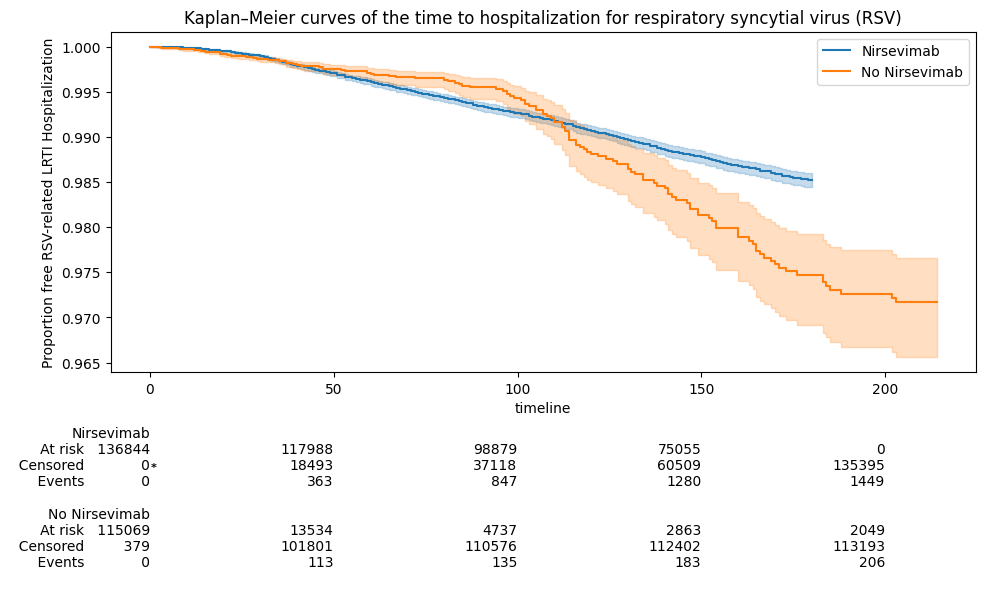

     test_statistic         p  -log2(p)
0 1        3.567614  0.058917  4.085175




,who,p_value
0,todo chile,0.059


In [15]:
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts

resultados_log_rank = []

T = df_mayer_vrs_agg["duration"]  
E = df_mayer_vrs_agg["event_vrs"]
inmunizado = df_mayer_vrs_agg["inmunizado"]  

# Crear el gráfico
plt.figure(figsize=(10, 6))  
ax = plt.subplot(111)

kmf_inmunizado = KaplanMeierFitter()
kmf_no_inmunizado = KaplanMeierFitter()

# Curva del grupo inmunizado
kmf_inmunizado.fit(
    T[inmunizado == 1], 
    event_observed=E[inmunizado == 1], 
    label="Nirsevimab"
)
kmf_inmunizado.plot_survival_function(ax=ax)

# Curva del grupo no inmunizado
kmf_no_inmunizado.fit(
    T[inmunizado == 0], 
    event_observed=E[inmunizado == 0], 
    label="No Nirsevimab"
)
kmf_no_inmunizado.plot_survival_function(ax=ax)

# Añadir las tablas de "At risk", "Censored" y "Events" para ambos grupos
add_at_risk_counts(kmf_inmunizado, kmf_no_inmunizado, ax=ax)
ax.text(x=0.1, y=0.953, s='*', fontsize=8, color='black', fontweight='bold')
ax.set_ylabel("Proportion free RSV-related LRTI Hospitalization")
# Ajustar diseño
plt.tight_layout()
plt.title(f'Kaplan–Meier curves of the time to hospitalization for respiratory syncytial virus (RSV)')
# plt.savefig(path_data/'KM_vrs.png', dpi=400, bbox_inches='tight')
# plt.savefig(path_data/'KM_vrs.eps', format='eps', bbox_inches='tight')
plt.savefig(path_data / 'KM_vrs.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()



log_rank = pairwise_logrank_test(T, inmunizado, E)
print(log_rank.summary)
print('\n')

p_value = round(log_rank.p_value[0],3) 
#test_stat = log_rank.test_statistic[0]  

resultados_log_rank.append({
    'who': "todo chile",
    'p_value': p_value #,'test_statistic': test_stat
})

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)

In [20]:
df_mayer_vrs_agg.groupby('inmunizado').duration.max()

inmunizado
0    214.0
1    180.0
Name: duration, dtype: float64

In [35]:
df_mayer_vrs_agg.query('event_vrs==1').query('duration>180')

,RUN,duration,inmunizado,event_vrs
80511,524cb7f3bb36c5673ccf9a30ae457b7ec2d9bf0d413417608c5239d65edfd2dc,202.0,0,1
135562,8a1177d2ae153d2d3278cbe2c7e44d2ce47d4433fd47375b8bf300cef1a76a34,188.0,0,1
177037,b3e75e82dd54aff16003b962a2572b1d3c36cb0d1631aea3b3b2f45948fe91b6,203.0,0,1
186888,bddfdabc924793b8d58967b97d6797197a68b084aa716d08c03b72aa77471e41,184.0,0,1
189296,c0504e53e3fd2b9e919f857a8cb3b01d14420580ce35c1744e4bc8a4edb110ba,183.0,0,1
205540,d0f30a665455d93873c60775a363b0398e7eab0ca62588e2cdb4006bef808265,183.0,0,1
227809,e75ed2c31f6ddb5428065810e0107a366b0b9875d8359f9313ca3b030f444f19,185.0,0,1


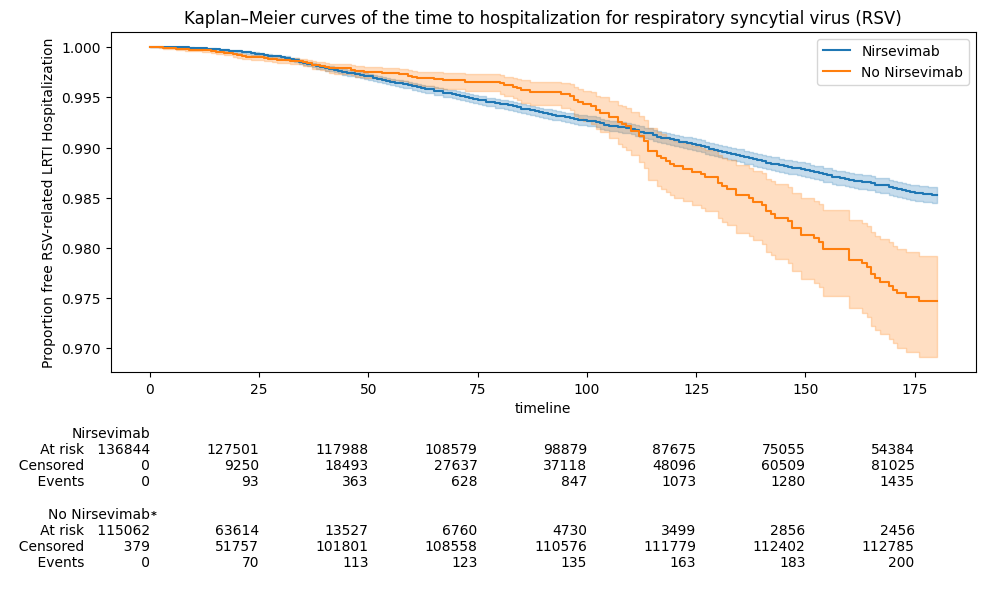

     test_statistic         p  -log2(p)
0 1        3.600922  0.057748  4.114097




,who,p_value
0,todo chile,0.058


In [36]:
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts

resultados_log_rank = []
df_mayer_vrs_agg_modi = df_mayer_vrs_agg.query('~((event_vrs==1) & (duration>180))').copy()

df_mayer_vrs_agg_modi.loc[(df_mayer_vrs_agg_modi.inmunizado==0) & (df_mayer_vrs_agg_modi.duration>180), 'duration'] = 180

T = df_mayer_vrs_agg_modi["duration"]  
E = df_mayer_vrs_agg_modi["event_vrs"]
inmunizado = df_mayer_vrs_agg_modi["inmunizado"]  

# Crear el gráfico
plt.figure(figsize=(10, 6))  
ax = plt.subplot(111)

kmf_inmunizado = KaplanMeierFitter()
kmf_no_inmunizado = KaplanMeierFitter()

# Curva del grupo inmunizado
kmf_inmunizado.fit(
    T[inmunizado == 1], 
    event_observed=E[inmunizado == 1], 
    label="Nirsevimab"
)
kmf_inmunizado.plot_survival_function(ax=ax)

# Curva del grupo no inmunizado
kmf_no_inmunizado.fit(
    T[inmunizado == 0], 
    event_observed=E[inmunizado == 0], 
    label="No Nirsevimab"
)
kmf_no_inmunizado.plot_survival_function(ax=ax)

# Añadir las tablas de "At risk", "Censored" y "Events" para ambos grupos
add_at_risk_counts(kmf_inmunizado, kmf_no_inmunizado, ax=ax)
ax.text(x=0.1, y=0.953, s='*', fontsize=8, color='black', fontweight='bold')
ax.set_ylabel("Proportion free RSV-related LRTI Hospitalization")
# Ajustar diseño
plt.tight_layout()
plt.title(f'Kaplan–Meier curves of the time to hospitalization for respiratory syncytial virus (RSV)')
# plt.savefig(path_data/'KM_vrs.png', dpi=400, bbox_inches='tight')
# plt.savefig(path_data/'KM_vrs.eps', format='eps', bbox_inches='tight')
plt.savefig(path_data / 'KM_vrs.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()



log_rank = pairwise_logrank_test(T, inmunizado, E)
print(log_rank.summary)
print('\n')

p_value = round(log_rank.p_value[0],3) 
#test_stat = log_rank.test_statistic[0]  

resultados_log_rank.append({
    'who': "todo chile",
    'p_value': p_value #,'test_statistic': test_stat
})

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)

KM subgrupos

In [38]:
df_f_vrs[['RUN','eleg_2025','eleg_group']]

,RUN,eleg_2025,eleg_group
135841,3c31cd20e67983bbcbcb61c7592af2e821096926c69252ab168bf54bce450a90,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
135883,879cd5d30663b31e5090525abbbecc8a521dedfcdaf0b4666a450c301c91397f,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
135890,5b9f0131f1b5b73979c1c1a8df086ad4fa6e8af510f0fbe95db73ae4a072eb4a,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
135891,b37178df925ca79e7f620d488a587e79e719a069492dd3d0f9c924cc6b9d1ade,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
135893,52b1e7e66851fa1ca81d04108d324898ab9c1e8073eebc78f128a311f514f024,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
...,...,...,...
271666,1bb2a460eb147d5e35437ee7acc748bc8bea8419c57eba94263dd976086fc0e5,SEASONAL,seasonal_2025
317856,62ca652d4c993c2a187f0bec061f35b32bc99e1c9adae326c098935262592b56,SEASONAL,seasonal_2025
223188,a45f085bf78e5c1689bccafcdd890c109eddbe1a4cc81bbfdd415e6aca2451e8,CATCH_UP,exceso_seasonal_2024_and_catchup_2025
333220,94bc8704f9390d53cfc8d40a5cf963bf6c01b165a8a0668512517e1901751874,SEASONAL,seasonal_2025


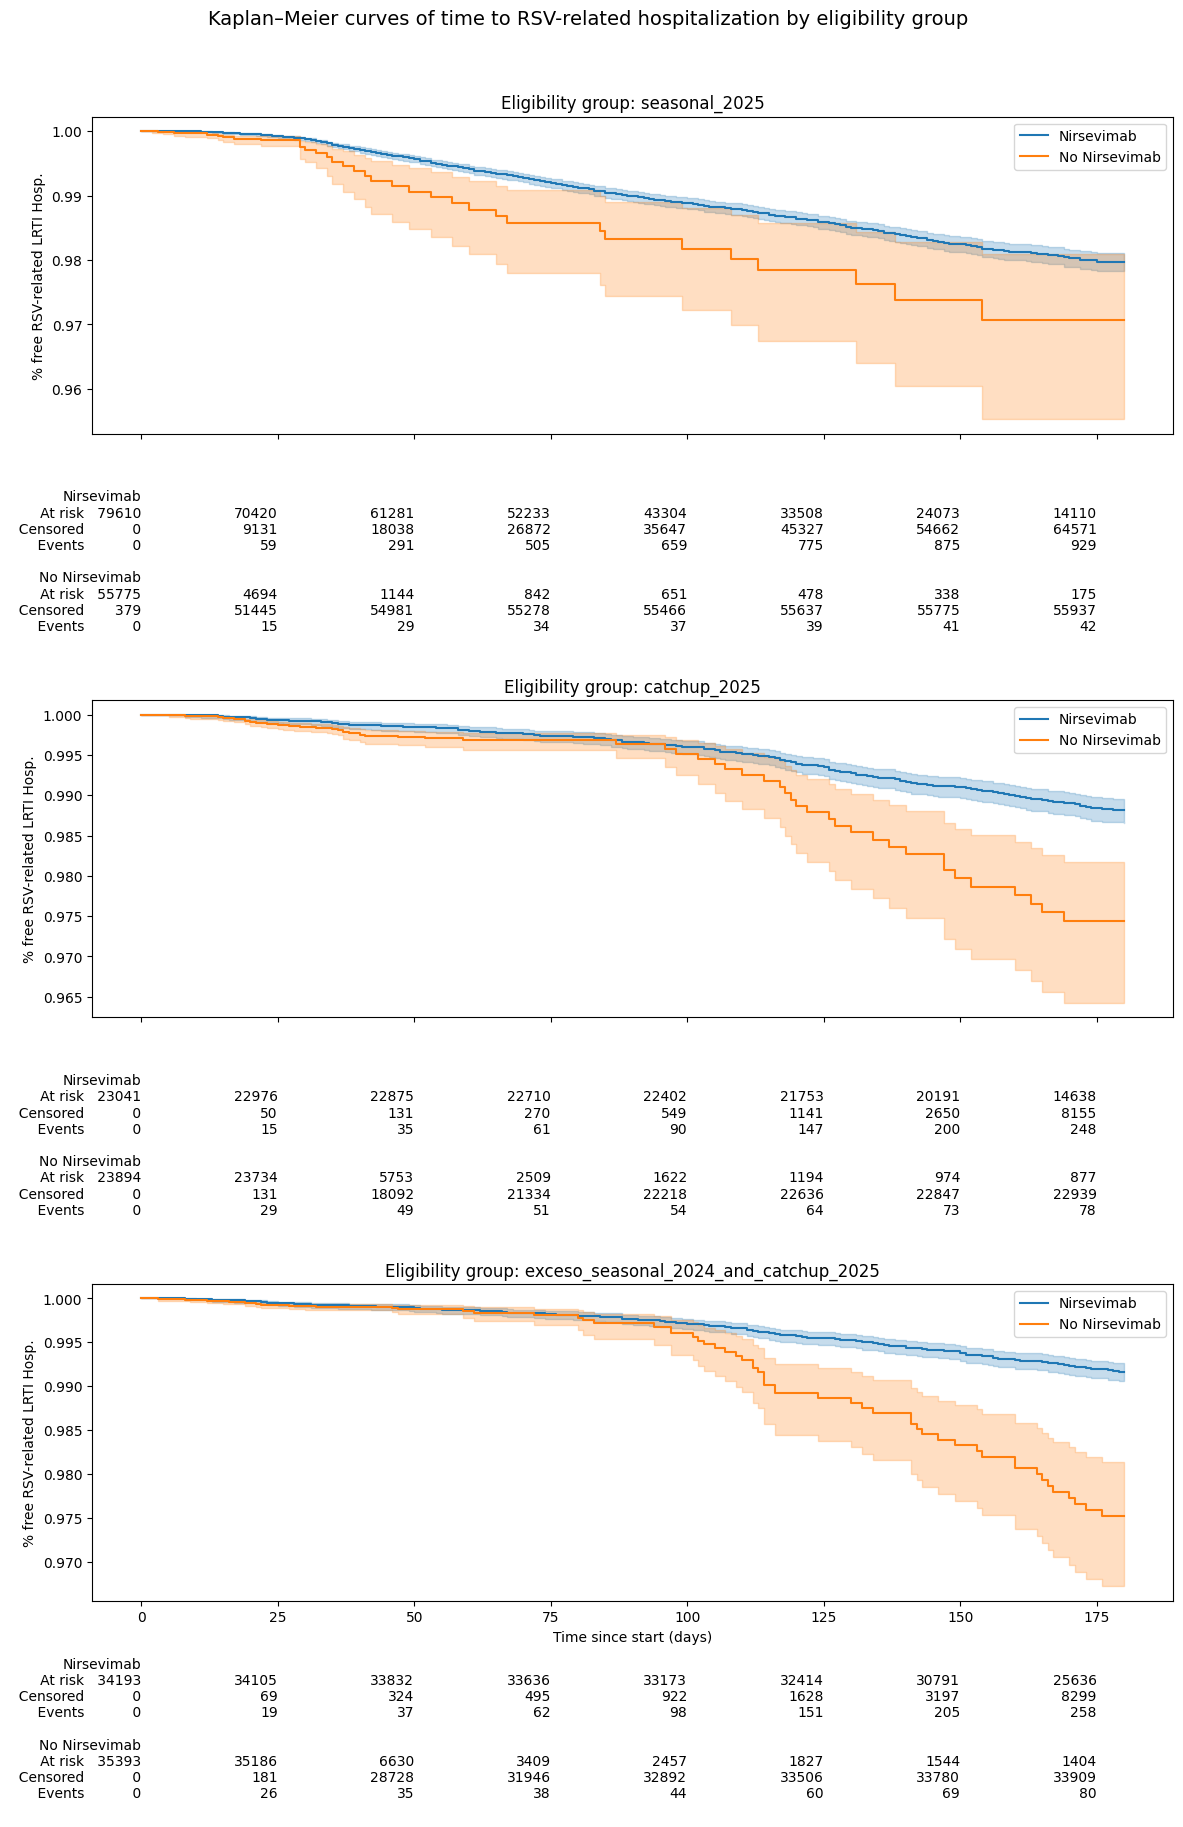

In [51]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt
import numpy as np


df_mayer_vrs_agg_modi = df_mayer_vrs_agg.query('~((event_vrs==1) & (duration>180))').copy()
df_mayer_vrs_agg_modi.loc[(df_mayer_vrs_agg_modi.inmunizado==0) & (df_mayer_vrs_agg_modi.duration>180), 'duration'] = 180
df_mayer_vrs_agg_modi = df_mayer_vrs_agg_modi.merge(df_f_vrs[['RUN','eleg_group']], how='left',on='RUN')

T = df_mayer_vrs_agg_modi["duration"]
E = df_mayer_vrs_agg_modi["event_vrs"]
inmunizado = df_mayer_vrs_agg_modi["inmunizado"]
groups = df_mayer_vrs_agg_modi["eleg_group"]

# Grupos únicos
unique_groups = groups.dropna().unique()
n_groups = len(unique_groups)

# Crear subplots
fig, axes = plt.subplots(
    nrows=n_groups,
    ncols=1,
    figsize=(12, 6 * n_groups),
    sharex=True
)

# Asegurar que axes sea iterable
if n_groups == 1:
    axes = [axes]

# Loop por grupo
for ax, g in zip(axes, unique_groups):

    mask_group = groups == g

    T_g = T[mask_group]
    E_g = E[mask_group]
    inmunizado_g = inmunizado[mask_group]

    kmf_inm = KaplanMeierFitter()
    kmf_no = KaplanMeierFitter()

    # Inmunizados
    kmf_inm.fit(
        T_g[inmunizado_g == 1],
        event_observed=E_g[inmunizado_g == 1],
        label="Nirsevimab"
    )
    kmf_inm.plot_survival_function(ax=ax, ci_show=True)

    # No inmunizados
    kmf_no.fit(
        T_g[inmunizado_g == 0],
        event_observed=E_g[inmunizado_g == 0],
        label="No Nirsevimab"
    )
    kmf_no.plot_survival_function(ax=ax, ci_show=True)

    # At risk table
    add_at_risk_counts(kmf_inm, kmf_no, ax=ax)

    ax.set_title(f"Eligibility group: {g}")
    ax.set_ylabel("% free RSV-related LRTI Hosp.")
    ax.legend()

axes[-1].set_xlabel("Time since start (days)")

plt.suptitle(
    "Kaplan–Meier curves of time to RSV-related hospitalization by eligibility group",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
# plt.savefig(path_data / "KM_vrs_by_eleg_group.pdf", dpi=400, bbox_inches="tight")
plt.show()


ANÁLISIS NO ELEGIBILIDADES

Selecciono todos los ruts que recibieron vacuna el 2024:

In [60]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr
df_f_any, df_f_LRTI, df_f_vrs_25, df_f_upc_25 = filtros_IH_new(df_pf_2025,cohort='2025')
df_f_any, df_f_LRTI, df_f_vrs_24, df_f_upc_24 = filtros_IH_new(df_pf_2025,cohort='2024')
df_f_any, df_f_LRTI, df_f_vrs_both, df_f_upc_both = filtros_IH_new(df_pf_2025,cohort='both')

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [ ]:
lista_ruts_vacunados_2024_co24 = df_f_vrs_24[df_f_vrs_24.fechaInm <= pd.to_datetime('2024-09-30')].RUN.unique()

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import sys, pathlib, os
import pickle
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

PROJECTS_DIR = pathlib.Path(os.getcwd()).resolve().parents[1]   # .../Proyectos

#  Añadimos a sys.path sólo si no está
if str(PROJECTS_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECTS_DIR))
    
from Efectividad_Nirse.Code.preproces_prod3 import *

def son_similares(cadena1, cadena2):
    return SequenceMatcher(None, cadena1, cadena2).ratio()

path_actual = Path.cwd()
path_data_nirse = path_actual.parent.parent / 'Nirse_cl' / 'Data'
path_eff_data = path_actual.parent.parent / 'Efectividad_Nirse' / 'Data'

new = pd.read_csv(path_data_nirse / '2025-04-22_Egresos2024.csv',encoding= 'latin1', sep = '|')#pd.read_csv(path_data / '2024-12-16_Egresos.csv',encoding= 'latin1', sep = '|')
new_2025 = pd.read_csv(path_data_nirse / '2025-12-04_Egresos2025.csv',encoding= 'latin1', sep = '|') # 2025-08-18_Egresos2025 este archivo anda bien 
egresos = pd.read_csv(path_data_nirse / "egresos.csv",encoding = "latin1",sep="|")

egresos = pd.concat([egresos,new,new_2025])
runes_raros = ['db97ccd245df4a064b20e703623e43804e14dce53f3bb5befb947e0803dd6fd0','ad9e5f32c7e34b52e22b5778b45bd95476c79bed20c550712e75fb43e409085c'] # SON 2 WEONES HIGH RISK DE LA ALEMNA SANTIAGO CON COMUNA INCORRECTA
egresos.loc[egresos.RUT.isin(runes_raros),'COMUNA'] = 13114.0

# file = path_data / "tributacion_egresos hospitalarios_2025.xlsx"

# trib_publi = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SS",  
#     skiprows=0
# )

# trib_priv = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SEREMI",
#     skiprows=0
# )

# trib = pd.concat([trib_publi,trib_priv])

trib_publi = pd.read_excel(
    path_data_nirse / "EstadoCargaIEEH_SS.xlsx",
    sheet_name="EstadoCargaIEEH_SS",  
    skiprows=0
)

trib_priv = pd.read_excel(
    path_data_nirse / "EstadoCargaIEEH_SEREMI.xlsx",
    sheet_name="EstadoCargaIEEH_SEREMI",
    skiprows=0
)

trib = pd.concat([trib_publi,trib_priv])  

comunas = (
    pd.read_excel(path_data_nirse/"comunas.xlsx")
    .drop_duplicates()
    .rename(columns = {'C_COM': 'COMUNA','NOM_REG':'NOMBRE_REGION'})
)
diagnosticos_upc = [406, 412, 415, 405, 411, 414, 310, 311, 312, 320, 323, 324]
areasMB = [401, 402, 403, 404, 407, 408, 409, 410, 413]

trib['CodigoEstablecimiento'] = trib['Codigo Establecimiento']

acusados = trib[trib['May'].isna()].CodigoEstablecimiento.dropna().astype(int)
cols_diagnostico = ['AREA_FUNC_I',
                    'AREAF_1_TRAS', 
                    'AREAF_2_TRAS', 
                    'AREAF_3_TRAS', 
                    'AREAF_4_TRAS', 
                    'AREAF_5_TRAS', 
                    'AREAF_6_TRAS', 
                    'AREAF_7_TRAS', 
                    'AREAF_8_TRAS', 
                    'AREAF_9_TRAS']

tras_date = {'AREA_FUNC_I': 'fechaIng',
             'AREAF_1_TRAS':'fecha_tras_1',
             'AREAF_2_TRAS':'fecha_tras_2',
             'AREAF_3_TRAS':'fecha_tras_3',
             'AREAF_4_TRAS':'fecha_tras_4',
             'AREAF_5_TRAS':'fecha_tras_5',
             'AREAF_6_TRAS':'fecha_tras_6', 
             'AREAF_7_TRAS':'fecha_tras_7', 
             'AREAF_8_TRAS':'fecha_tras_8', 
             'AREAF_9_TRAS':'fecha_tras_9'}

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

egresos_plus = (egresos
                .rename(columns={'RUT':'RUN'})
                .merge(comunas,how='left',on ='COMUNA')
                .assign(FECHA_NAC     = lambda x: pd.to_datetime({'year': x['A_NAC'], 'month': x['M_NAC'], 'day': x['D_NAC']}, format='%Y-%m-%d'),
                        fechaIng      = lambda x: pd.to_datetime({'year': x['ANO_ING'], 'month': x['MES_ING'], 'day': x['DIA_ING']}, format='%Y-%m-%d'),
                        fechaEgr      = lambda x: pd.to_datetime({'year': x['ANO_EGR'], 'month': x['MES_EGR'], 'day': x['DIA_EGR']}, format='%Y-%m-%d'),
                        NOMBRE_REGION = lambda x: x['NOMBRE_REGION'].str.replace('Región', '').str.strip().fillna('Ignorada'),
                        age_years     = lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 365),
                        age_months    = lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 28 ),
                        # FECHA_NAC=lambda x: pd.to_datetime(x["FECHA_NAC"], format="%Y-%m-%d"),
                        # fechaIng=lambda x: pd.to_datetime(x["fechaIng"], format="%Y-%m-%d")
                        ))
subset_columnas = ['RUN', 'FECHA_NAC','fechaIng','SEXO','NOMBRE_REGION','AREA_FUNC_I', 'ANO_ING','DIAG1','ESTAB', 'DIAS_ESTAD', 'fechaEgr', 'PREVI','age_years', 'age_months',
                   'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS','DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'DIA_3_TRAS',
                   'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS','ANO_4_TRAS', 'AREAF_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 
                   'ANO_5_TRAS','AREAF_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS',
                   'AREAF_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS','AREAF_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS', 'AREAF_9_TRAS']

df_filtrado = egresos_plus[subset_columnas]
vrs_cods = ['J121', 'J205','J219', 'J210', 'B974']

df_filtrado_vrs = (
    df_filtrado[df_filtrado[['DIAG1']].isin(vrs_cods).any(axis=1)]
)


['J121' 'J210' 'J219' 'J205']


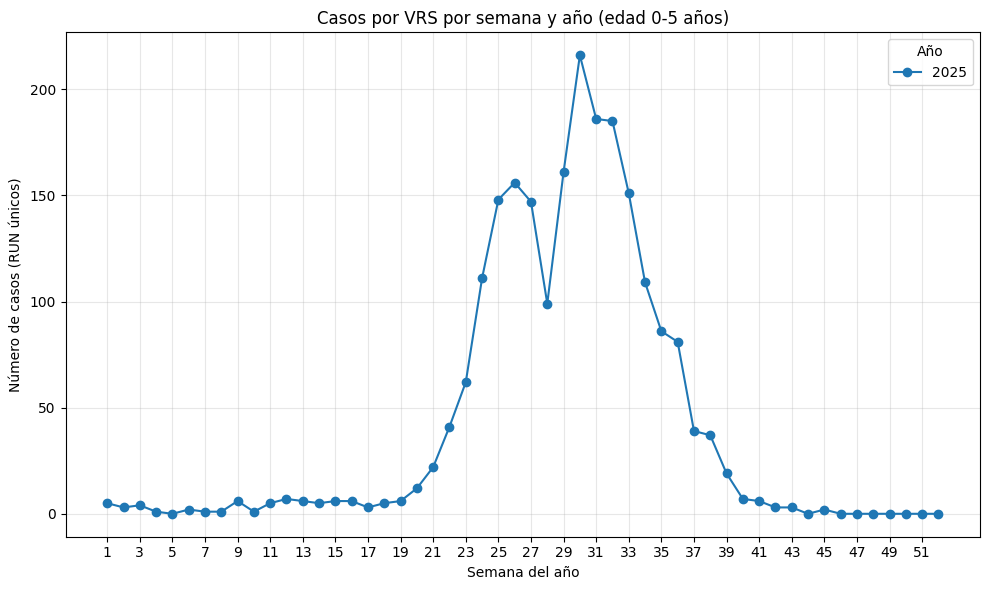

In [ ]:
def curvas_por_ano_semana(df, list_ruts_filtro=None, acumulado=False, age=None,year_picked=None):


    print(df.DIAG1.unique())
    anios_interes = [2019, 2022, 2023, 2024, 2025]
    if year_picked != None:
        anios_interes = [year_picked]
    # --- Filtro por edad (si corresponde) ---
    df_age = df.copy()

    if age is not None:
        try:
            low_str, high_str = age.split('-')
            low = float(low_str.strip())
            high = float(high_str.strip())
        except Exception:
            raise ValueError("El parámetro 'age' debe tener formato 'a-b', por ejemplo '0-1' o '1-4'.")

        # Aseguramos tipo numérico de age_years por si acaso
        df_age = df_age.assign(age_years=lambda d: pd.to_numeric(d['age_years'], errors='coerce'))
        # Filtro: [low, high)
        df_age = df_age.query("@low <= age_years < @high") # .query("age_years >= @low and age_years < @high")

        if list_ruts_filtro is not None:
            df_age = df_age.query('RUN.isin(@list_ruts_filtro)')
            
            
    # --- Construcción de la tabla año-semana ---
    tabla = (
        df_age
        .assign(
            year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int),
            week=lambda d: d['fechaIng'].dt.isocalendar().week.astype(int),
        )
        .query("year in @anios_interes")
        .groupby(['year', 'week'], as_index=False)
        .agg(n_casos=('RUN', 'nunique'))
        .pivot(index='week', columns='year', values='n_casos')
        .reindex(range(1, 53))
        .fillna(0)
    )

    # --- Acumulado si se pide ---
    if acumulado:
        tabla = tabla.cumsum()

    # --- Texto extra para títulos / labels según edad ---
    if age is None:
        age_text = ""
    else:
        age_text = f" (edad {age} años)"

    # --- Gráfico ---
    plt.figure(figsize=(10, 6))

    for year in anios_interes:
        if year in tabla.columns:
            plt.plot(
                tabla.index,
                tabla[year],
                marker='o',
                label=f"{year}" + (" (acum.)" if acumulado else "")
            )

    plt.xlabel('Semana del año')
    plt.ylabel('Número de casos (RUN únicos)' + (" acumulados" if acumulado else ""))
    plt.title('Casos por VRS por semana y año' + age_text + (" (acumulado)" if acumulado else ""))
    plt.xticks(range(1, 53, 2))
    plt.grid(alpha=0.3)
    plt.legend(title='Año')
    plt.tight_layout()
    plt.show()

curvas_por_ano_semana(df_filtrado_rota_1,list_ruts_filtro=lista_ruts_vacunados_2024_co24,acumulado=False,age='0-5',year_picked=2025)


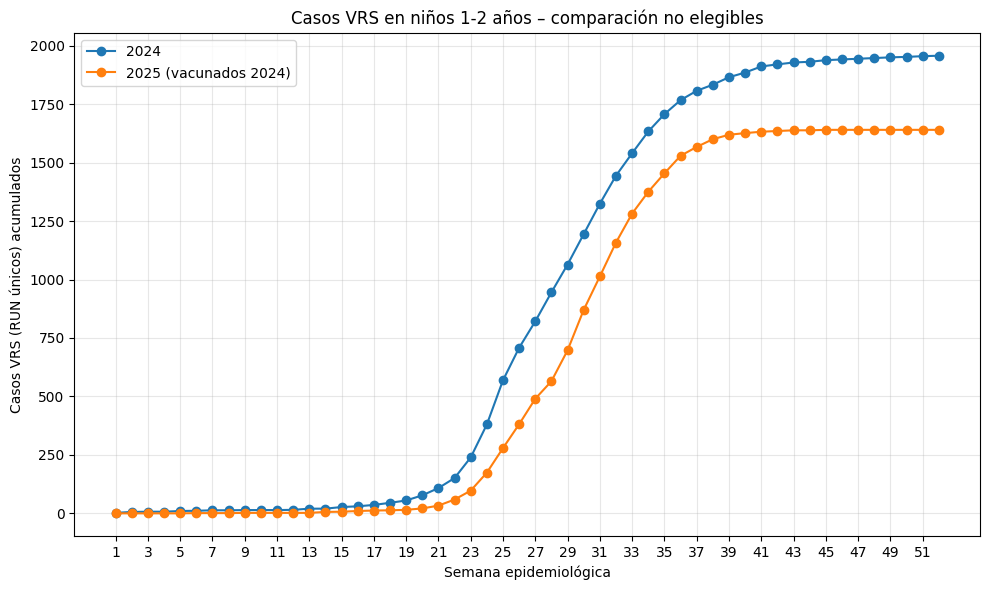

In [90]:
def curvas_por_ano_semana_no_elegibles(
    df,
    list_ruts_vacunados_2024,
    acumulado=False,
    age='1-2',
    year_baseline=2024,
    year_compare=2025
):

    # --- Filtro por edad ---
    low, high = map(float, age.split('-'))
    df_age = (
        df
        .assign(age_years=lambda d: pd.to_numeric(d['age_years'], errors='coerce'))
        .query("@low <= age_years < @high")
    )

    # --- Construcción year-week ---
    df_age = df_age.assign(
        year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int),
        week=lambda d: d['fechaIng'].dt.isocalendar().week.astype(int),
    )

    # --- Año baseline: SIN filtro por vacunación ---
    tabla_baseline = (
        df_age
        .query("year == @year_baseline")
        .groupby('week', as_index=False)
        .agg(n_casos=('RUN', 'nunique'))
        .set_index('week')
        .reindex(range(1, 53))
        .fillna(0)
    )

    # --- Año comparación (2025): SOLO vacunados en 2024 ---
    tabla_compare = (
        df_age
        .query("year == @year_compare and RUN.isin(@list_ruts_vacunados_2024)")
        .groupby('week', as_index=False)
        .agg(n_casos=('RUN', 'nunique'))
        .set_index('week')
        .reindex(range(1, 53))
        .fillna(0)
    )

    if acumulado:
        tabla_baseline = tabla_baseline.cumsum()
        tabla_compare = tabla_compare.cumsum()

    # --- Gráfico ---
    plt.figure(figsize=(10, 6))

    plt.plot(
        tabla_baseline.index,
        tabla_baseline['n_casos'],
        marker='o',
        label=f"{year_baseline}"
    )

    plt.plot(
        tabla_compare.index,
        tabla_compare['n_casos'],
        marker='o',
        label=f"{year_compare} (vacunados {year_baseline})"
    )

    plt.xlabel('Semana epidemiológica')
    plt.ylabel('Casos VRS (RUN únicos)' + (' acumulados' if acumulado else ''))
    plt.title(f'Casos VRS en niños {age} años – comparación no elegibles')
    plt.xticks(range(1, 53, 2))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


curvas_por_ano_semana_no_elegibles(
    df_filtrado_rota_1,
    list_ruts_vacunados_2024=lista_ruts_vacunados_2024_co24,
    acumulado=True,
    age='1-2',
    year_baseline=2024,
    year_compare=2025
)

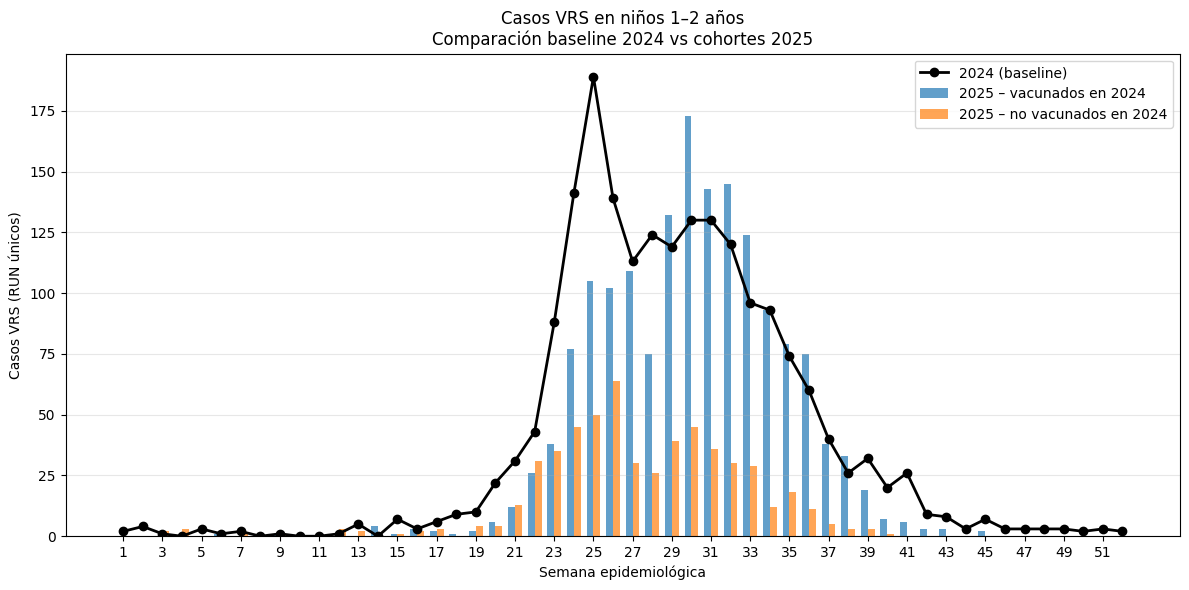

In [93]:
lista_ruts_vacunados_2024=lista_ruts_vacunados_2024_co24

df_plot = (
    df_filtrado_rota_1
    .assign(age_years=lambda d: pd.to_numeric(d['age_years'], errors='coerce'))
    .query("1 <= age_years < 2")
    .assign(
        year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int),
        week=lambda d: d['fechaIng'].dt.isocalendar().week.astype(int)
    )
)

tabla_2024 = (
    df_plot
    .query("year == 2024")
    .groupby('week', as_index=False)
    .agg(n_casos=('RUN', 'nunique'))
    .set_index('week')
    .reindex(range(1, 53))
    .fillna(0)
)

tabla_2025_vac = (
    df_plot
    .query("year == 2025 and RUN.isin(@lista_ruts_vacunados_2024)")
    .groupby('week', as_index=False)
    .agg(n_casos=('RUN', 'nunique'))
    .set_index('week')
    .reindex(range(1, 53))
    .fillna(0)
)

tabla_2025_novac = (
    df_plot
    .query("year == 2025 and not RUN.isin(@lista_ruts_vacunados_2024)")
    .groupby('week', as_index=False)
    .agg(n_casos=('RUN', 'nunique'))
    .set_index('week')
    .reindex(range(1, 53))
    .fillna(0)
)

weeks = np.arange(1, 53)
bar_width = 0.35

plt.figure(figsize=(12, 6))

# --- Línea 2024 ---
plt.plot(
    weeks,
    tabla_2024['n_casos'],
    color='black',
    linewidth=2,
    marker='o',
    label='2024 (baseline)'
)

# --- Barras 2025 ---
plt.bar(
    weeks - bar_width/2,
    tabla_2025_vac['n_casos'],
    width=bar_width,
    alpha=0.7,
    label='2025 – vacunados en 2024'
)

plt.bar(
    weeks + bar_width/2,
    tabla_2025_novac['n_casos'],
    width=bar_width,
    alpha=0.7,
    label='2025 – no vacunados en 2024'
)

# --- Estética ---
plt.xlabel('Semana epidemiológica')
plt.ylabel('Casos VRS (RUN únicos)')
plt.title('Casos VRS en niños 1–2 años\nComparación baseline 2024 vs cohortes 2025')
plt.xticks(range(1, 53, 2))
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


KM de niños 2024 hasta el infinito

In [98]:
df_cox_vrs_both, df_cox_upc_both, df_f_vrs_both, df_f_upc_both = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 40,group_age=False,weeks_inm=False,cohort='both',fin_inmune=False)

################# LO DE ABAJO SOO ACTIVAR SI ESQUE group_age=TRUE ######################################
# df_cox_vrs_both['group_age'] = df_cox_vrs_both[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
#     lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

# df_cox_upc_both['group_age'] = df_cox_upc_both[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
#     lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2539
ruts perdidos por filtro semanas y peso:  1134
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [99]:
lista_ruts_2024 = df_f_vrs_24.RUN.unique()

df_vrs_post_both = df_cox_vrs_both.query('RUN.isin(@lista_ruts_2024)').copy()
df_upc_post_both = df_cox_upc_both.query('RUN.isin(@lista_ruts_2024)').copy()


chile_1 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA'] #best_eff
chile_2 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'TARAPACA','MAULE','NUBLE','BIOBIO'] #best_p_v
chile_3 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA','MAULE','NUBLE','BIOBIO','LOS RIOS'] #all_acceptable
chile_entero = ['METROPOLITANA', 'ATACAMA', 'BIOBIO', 'COQUIMBO', 'NUBLE', 'VALPARAISO', 'TARAPACA', 'ANTOFAGASTA', 'LOS LAGOS', 'ARAUCANIA',
                'LOS RIOS', 'AISEN', "O'HIGGINS", 'MAULE', 'ARICA Y PARINACOTA','MAGALLANES Y ANTARTICA']

# Diccionarios para mapeos de macrozonas
region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

region_to_macrozone_ciencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Region Metropolitana",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

for df in [df_vrs_post_both,df_upc_post_both]:
    df["chile_chico_1"] = df["region"].apply(lambda x: 1 if x in chile_1 else 0)
    df["chile_chico_2"] = df["region"].apply(lambda x: 1 if x in chile_2 else 0)
    df["chile_chico_3"] = df["region"].apply(lambda x: 1 if x in chile_3 else 0)
    df["chile_entero"] = df["region"].apply(lambda x: 1 if x in chile_entero else 0)
    df["macrozona_v1"] = df["region"].map(region_to_macrozone_agencia)
    df["macrozona_v2"] = df["region"].map(region_to_macrozone_ciencia)
    
df_mayer_vrs_both = (
    df_vrs_post_both
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs', 'macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']]
    .assign(duration = lambda x: x.stop - x.start)
)

df_mayer_upc_both = (
    df_upc_post_both
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_upc', 'macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']]
    .assign(duration = lambda x: x.stop - x.start)
)

aggre_vrs_both = (
    df_mayer_vrs_both
    .groupby(['RUN', 'event_vrs','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

aggre_upc_both = (
    df_mayer_upc_both
    .groupby(['RUN', 'event_upc','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

df_mayer_vrs_both = pd.merge(aggre_vrs_both, df_mayer_vrs_both[['RUN','macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']].drop_duplicates('RUN'), how='left', on='RUN')
df_mayer_upc_both = pd.merge(aggre_upc_both, df_mayer_upc_both[['RUN','macrozona_v1', 'region', 'Macrozona2','sexo','SEMANAS', 'chile_chico_1','eleg_2025']].drop_duplicates('RUN'), how='left', on='RUN')

def process_RUN_event(group,event):
    result = []
    
    # Agrupar por `inmunizado`
    for inmunizado_status, subset in group.groupby('inmunizado'):
        if inmunizado_status == 0:
            # Si `inmunizado = 0`, tiempo termina cuando hay event_vrs = 1 o cambia a inmunizado = 1
            event_row = subset[subset[event] == 1]
            if not event_row.empty:
                # Si hay un evento, sumar hasta esa fila
                total_duration = subset['duration'].iloc[:event_row.index[0] + 1].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 0,
                    event: 1
                })
            else:
                # Si no hay eventos, sumar toda la duración
                total_duration = subset['duration'].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 0,
                    event: 0
                })
        elif inmunizado_status == 1:
            # Si `inmunizado = 1`, tiempo termina cuando hay event_vrs = 1
            event_row = subset[subset[event] == 1]
            if not event_row.empty:
                # Sumar hasta el evento
                total_duration = subset['duration'].iloc[:event_row.index[0] + 1].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 1,
                    event: 1
                })
            else:
                # Si no hay eventos, sumar toda la duración
                total_duration = subset['duration'].sum()
                result.append({
                    'RUN': group['RUN'].iloc[0],
                    'duration': total_duration,
                    'inmunizado': 1,
                    event: 0
                })
    return pd.DataFrame(result)

def process_RUN_vrs(group):
    return process_RUN_event(group,'event_vrs')
    
def process_RUN_upc(group):
    return process_RUN_event(group,'event_upc')
    

# Aplicar la función por cada grupo de `RUN`
# df_mayer_vrs_agg = df_mayer_vrs[['RUN','event_vrs', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_vrs).reset_index(drop=True)
# df_mayer_upc_agg = df_mayer_upc[['RUN','event_upc', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_upc).reset_index(drop=True)

df_mayer_vrs_agg_both = df_mayer_vrs_both[['RUN','event_vrs', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_vrs).reset_index(drop=True)
df_mayer_upc_agg_both = df_mayer_upc_both[['RUN','event_upc', 'duration', 'inmunizado']].groupby('RUN', group_keys=False).apply(process_RUN_upc).reset_index(drop=True)

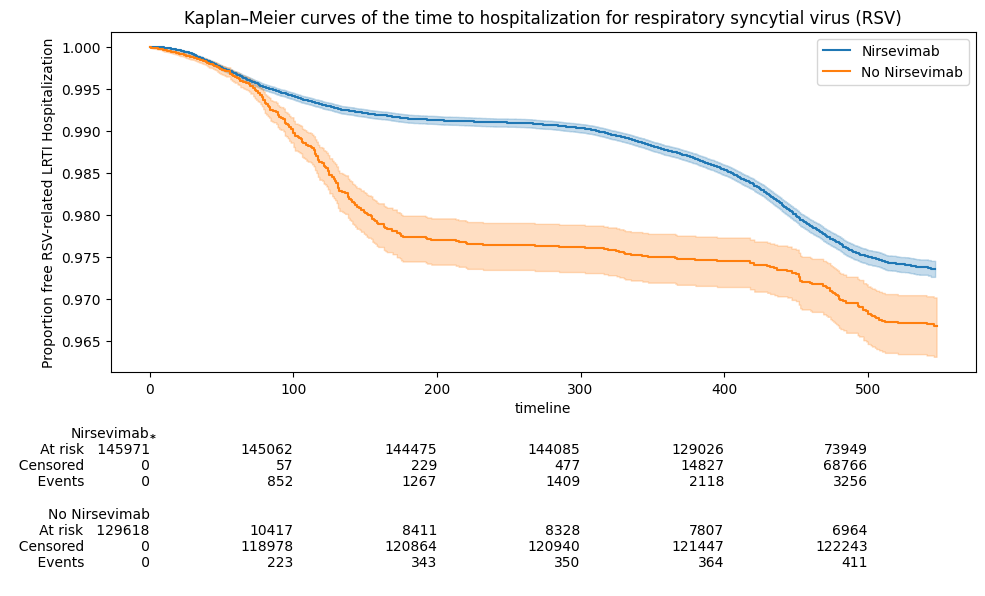

     test_statistic             p   -log2(p)
0 1        30.66332  3.069124e-08  24.957598




,who,p_value
0,todo chile,0.0


In [101]:
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts

resultados_log_rank = []

T = df_mayer_vrs_agg_both["duration"]  
E = df_mayer_vrs_agg_both["event_vrs"]
inmunizado = df_mayer_vrs_agg_both["inmunizado"]  

# Crear el gráfico
plt.figure(figsize=(10, 6))  
ax = plt.subplot(111)

kmf_inmunizado = KaplanMeierFitter()
kmf_no_inmunizado = KaplanMeierFitter()

# Curva del grupo inmunizado
kmf_inmunizado.fit(
    T[inmunizado == 1], 
    event_observed=E[inmunizado == 1], 
    label="Nirsevimab"
)
kmf_inmunizado.plot_survival_function(ax=ax)

# Curva del grupo no inmunizado
kmf_no_inmunizado.fit(
    T[inmunizado == 0], 
    event_observed=E[inmunizado == 0], 
    label="No Nirsevimab"
)
kmf_no_inmunizado.plot_survival_function(ax=ax)

# Añadir las tablas de "At risk", "Censored" y "Events" para ambos grupos
add_at_risk_counts(kmf_inmunizado, kmf_no_inmunizado, ax=ax)
ax.text(x=0.1, y=0.953, s='*', fontsize=8, color='black', fontweight='bold')
ax.set_ylabel("Proportion free RSV-related LRTI Hospitalization")
# Ajustar diseño
plt.tight_layout()
plt.title(f'Kaplan–Meier curves of the time to hospitalization for respiratory syncytial virus (RSV)')
# plt.savefig(path_data/'KM_vrs.png', dpi=400, bbox_inches='tight')
# plt.savefig(path_data/'KM_vrs.eps', format='eps', bbox_inches='tight')
plt.savefig(path_data / 'KM_vrs.pdf', format='pdf', dpi=400, bbox_inches='tight')
plt.show()



log_rank = pairwise_logrank_test(T, inmunizado, E)
print(log_rank.summary)
print('\n')

p_value = round(log_rank.p_value[0],3) 
#test_stat = log_rank.test_statistic[0]  

resultados_log_rank.append({
    'who': "todo chile",
    'p_value': p_value #,'test_statistic': test_stat
})

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)